In [21]:
import pandas as pd
import os
from IPython.display import display, Image, HTML

In [ ]:
def summarize_logs(base_path=".."):
    print("PHẦN 1: NHẬT KÝ HUẤN LUYỆN")
    print("="*60)
    
    log_res1_path = os.path.join(base_path, "logs", "resnet18_log.csv")
    if os.path.exists(log_res1_path):
        df_res1 = pd.read_csv(log_res1_path)
        best_idx = df_res1['val_acc'].idxmax()
        best_row = df_res1.loc[best_idx]
        print(f"1.1. ResNet18 huấn luyện trên HAM10000:")
        print(f"   - Tổng số Epoch đã chạy: {len(df_res1)}")
        print(f"   - Epoch đạt kết quả tốt nhất: {int(best_row['epoch'])}")
        print(f"   - Validation Accuracy cao nhất: {best_row['val_acc']:.4f}")
        print(f"   - Validation Loss tương ứng: {best_row['val_loss']:.4f}\n")
    else:
        print(f"1.1. Không tìm thấy file: {log_res1_path}\n")
    
    log_res2_path = os.path.join(base_path, "logs", "resnet18_derm7pt_log.csv")
    if os.path.exists(log_res2_path):
        df_res2 = pd.read_csv(log_res2_path)
        best_idx2 = df_res2['val_acc'].idxmax()
        best_row2 = df_res2.loc[best_idx2]
        print(f"1.2. ResNet18 Fine-tune trên tập Derm7pt:")
        print(f"   - Tổng số Epoch đã chạy: {len(df_res2)}")
        print(f"   - Epoch đạt kết quả tốt nhất: {int(best_row2['epoch'])}")
        print(f"   - Validation Accuracy cao nhất: {best_row2['val_acc']:.4f}")
        print(f"   - Validation Loss tương ứng: {best_row2['val_loss']:.4f}\n")
    else:
        print(f"1.2. Không tìm thấy file: {log_res2_path}\n")

summarize_logs()

PHẦN 1: NHẬT KÝ HUẤN LUYỆN
1.1. ResNet18 huấn luyện trên HAM10000:
   - Tổng số Epoch đã chạy: 10
   - Epoch đạt kết quả tốt nhất: 10
   - Validation Accuracy cao nhất: 0.6973
   - Validation Loss tương ứng: 0.7655

1.2. ResNet18 Fine-tune trên tập Derm7pt:
   - Tổng số Epoch đã chạy: 10
   - Epoch đạt kết quả tốt nhất: 10
   - Validation Accuracy cao nhất: 0.5961
   - Validation Loss tương ứng: 1.1743



In [30]:
def summarize_metrics(base_path=".."):
    print("PHẦN 2: ĐÁNH GIÁ & SO SÁNH")
    print("="*60)
    
    vit_metrics_path = os.path.join(base_path, "results", "ph06_evaluation_outputs", "ph06_evaluation_outputs", "vit_metrics_summary.csv")
    if os.path.exists(vit_metrics_path):
        df_vit = pd.read_csv(vit_metrics_path)
        print("2.1. Tổng quan hiệu năng mô hình ViT (Fine-tune trên Derm7pt):")
        for col in df_vit.columns:
            if col != 'Model':
                print(f"   - {col}: {df_vit[col].iloc[0]:.4f}")
        print("\n")
    else:
        print(f"2.1. Không tìm thấy file: {vit_metrics_path}\n")

    comp_metrics_path = os.path.join(base_path, "results", "ph07_model_comparison", "metrics_comparison_summary.csv")
    if os.path.exists(comp_metrics_path):
        df_comp = pd.read_csv(comp_metrics_path)
        print("2.2. Bảng so sánh chi tiết trên từng lớp (ResNet18 vs ViT):")
        print(df_comp.to_string(index=False))
        print("\n")
    else:
        print(f"2.2. Không tìm thấy file: {comp_metrics_path}\n")

summarize_metrics()

PHẦN 2: ĐÁNH GIÁ & SO SÁNH
2.1. Tổng quan hiệu năng mô hình ViT (Fine-tune trên Derm7pt):
   - Accuracy: 0.7823
   - Precision: 0.7825
   - Recall: 0.7823
   - F1-Score: 0.7813


2.2. Bảng so sánh chi tiết trên từng lớp (ResNet18 vs ViT):
Class  Precision (ResNet18)  Precision (ViT)  Recall (ResNet18)  Recall (ViT)  F1-Score (ResNet18)  F1-Score (ViT)
  bcc                  0.24             0.82               0.69          0.56                 0.36            0.67
  mel                  0.57             0.73               0.41          0.73                 0.47            0.73
 misc                  0.40             0.63               0.65          0.60                 0.50            0.62
nevus                  0.85             0.85               0.70          0.87                 0.77            0.86
   sk                  0.16             0.57               0.26          0.63                 0.20            0.60




PHẦN 3: VISUALIZATIONS


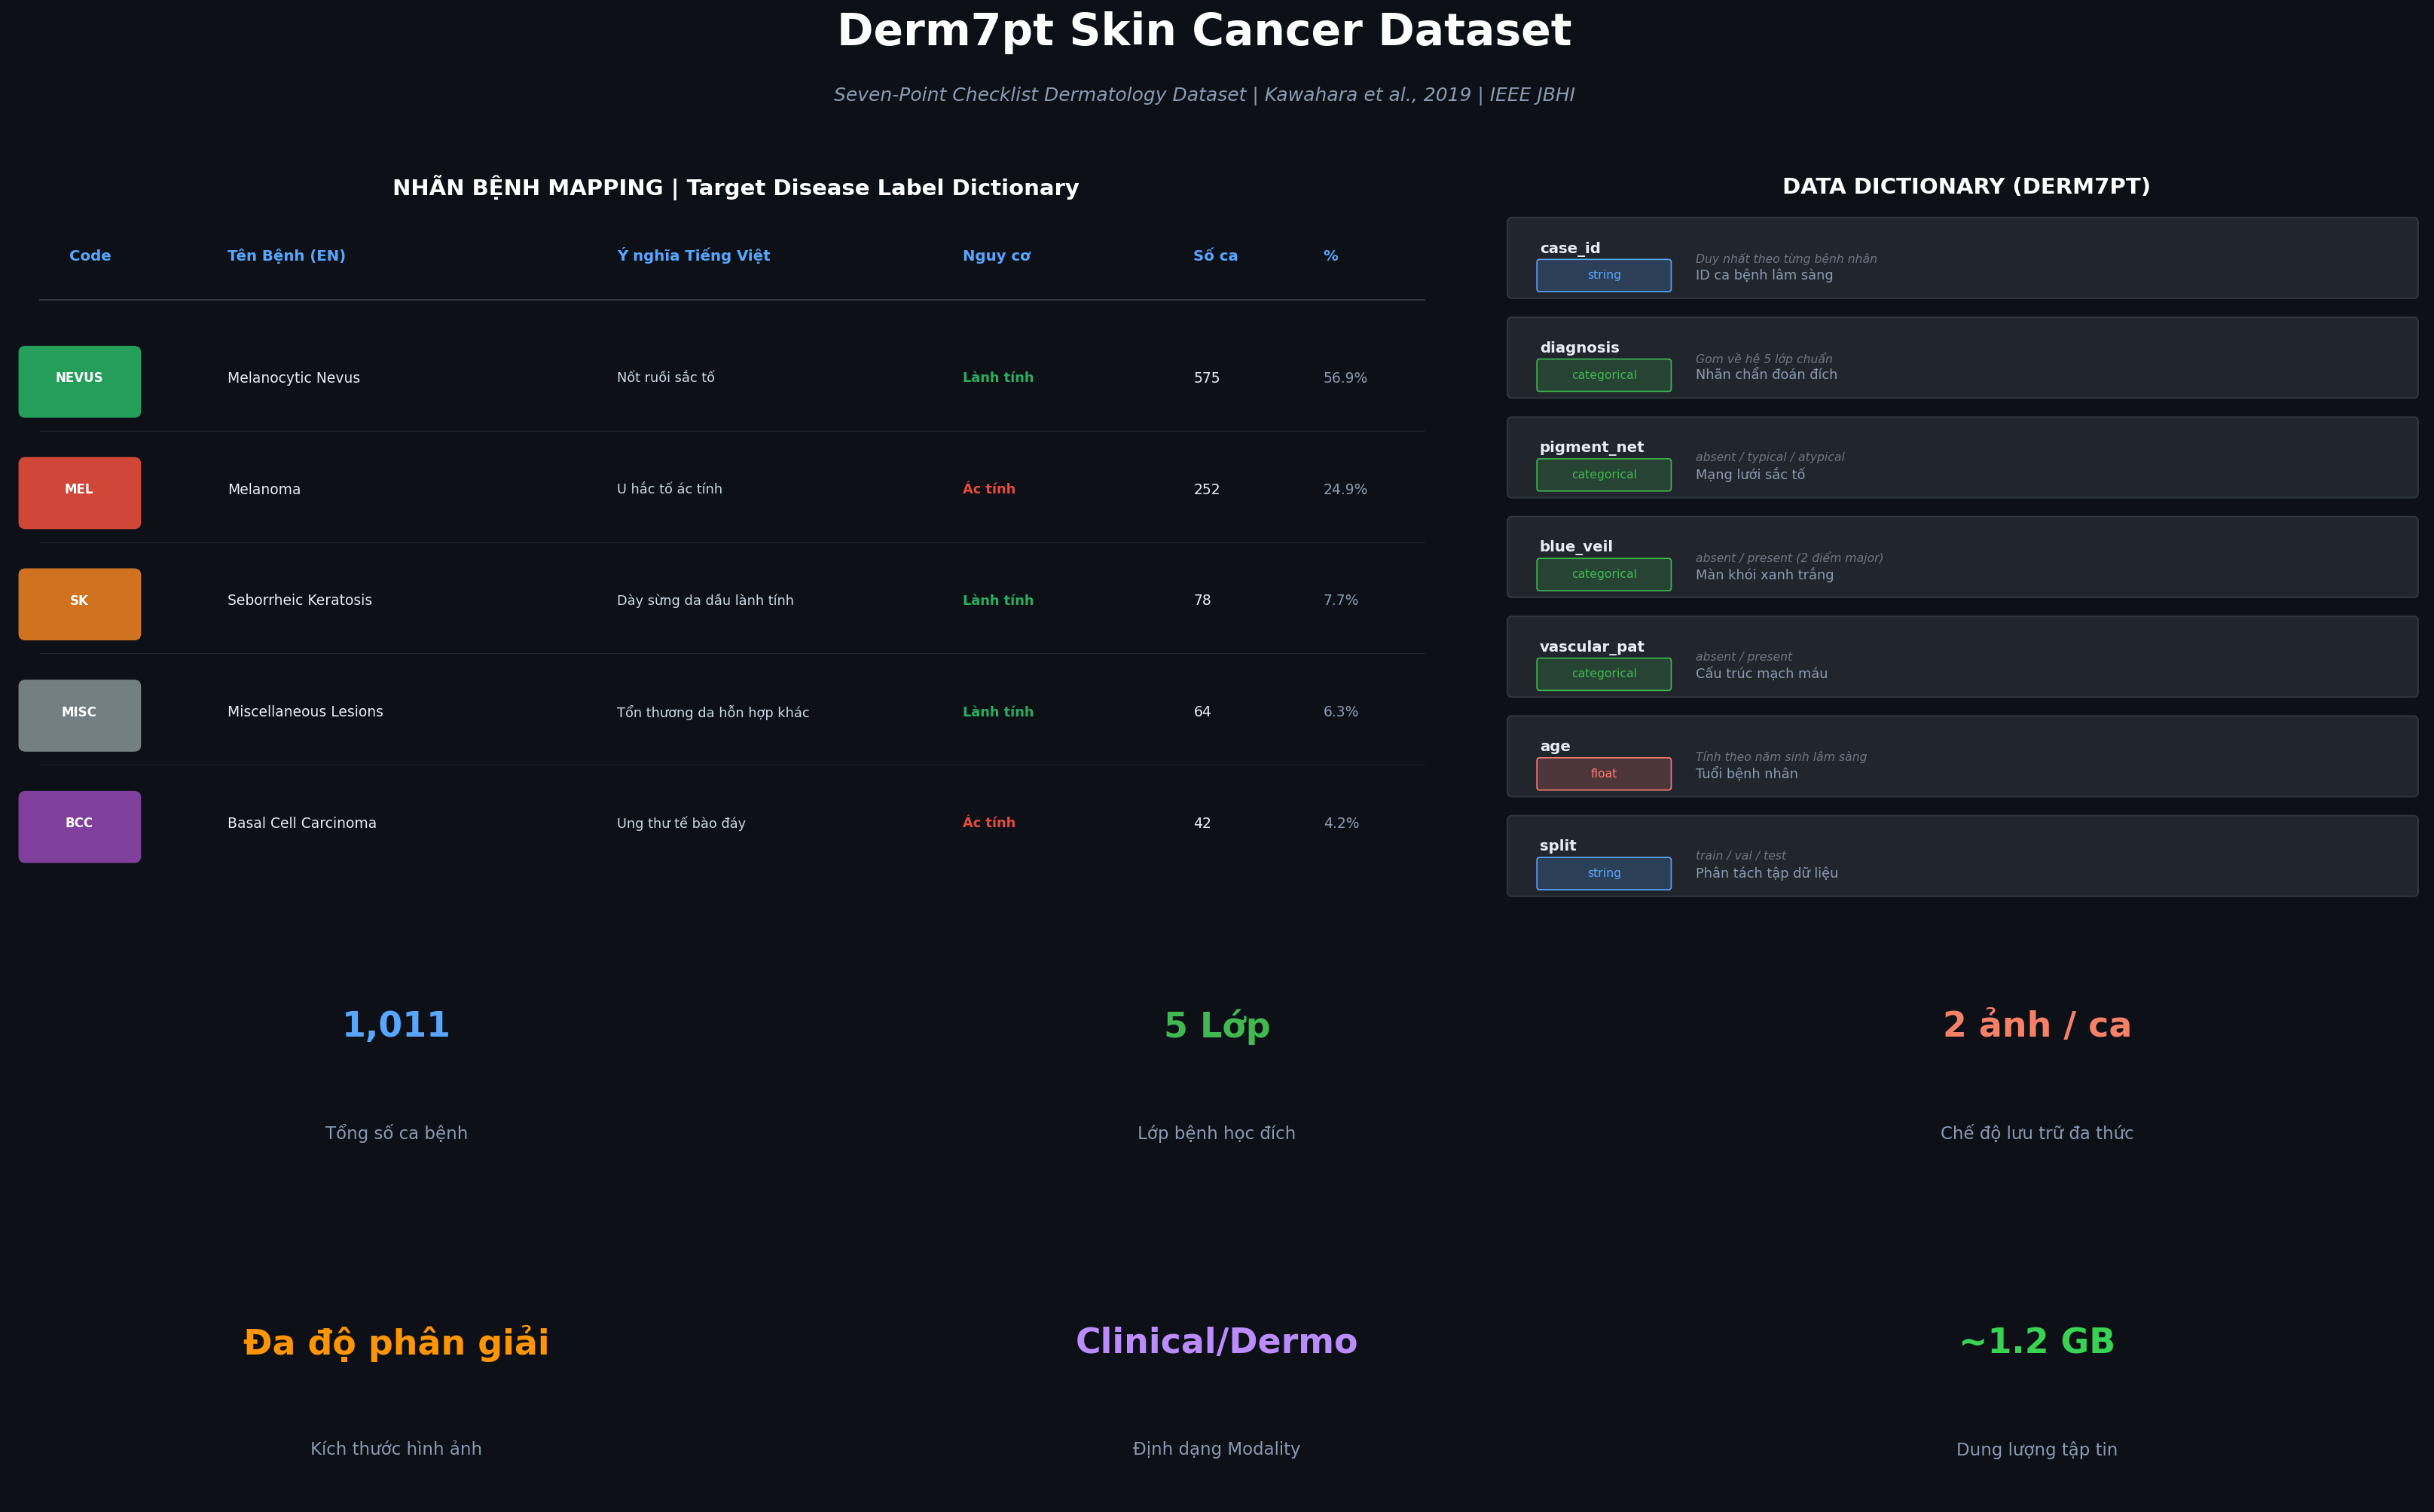

--------------------------------------------------------------------------------


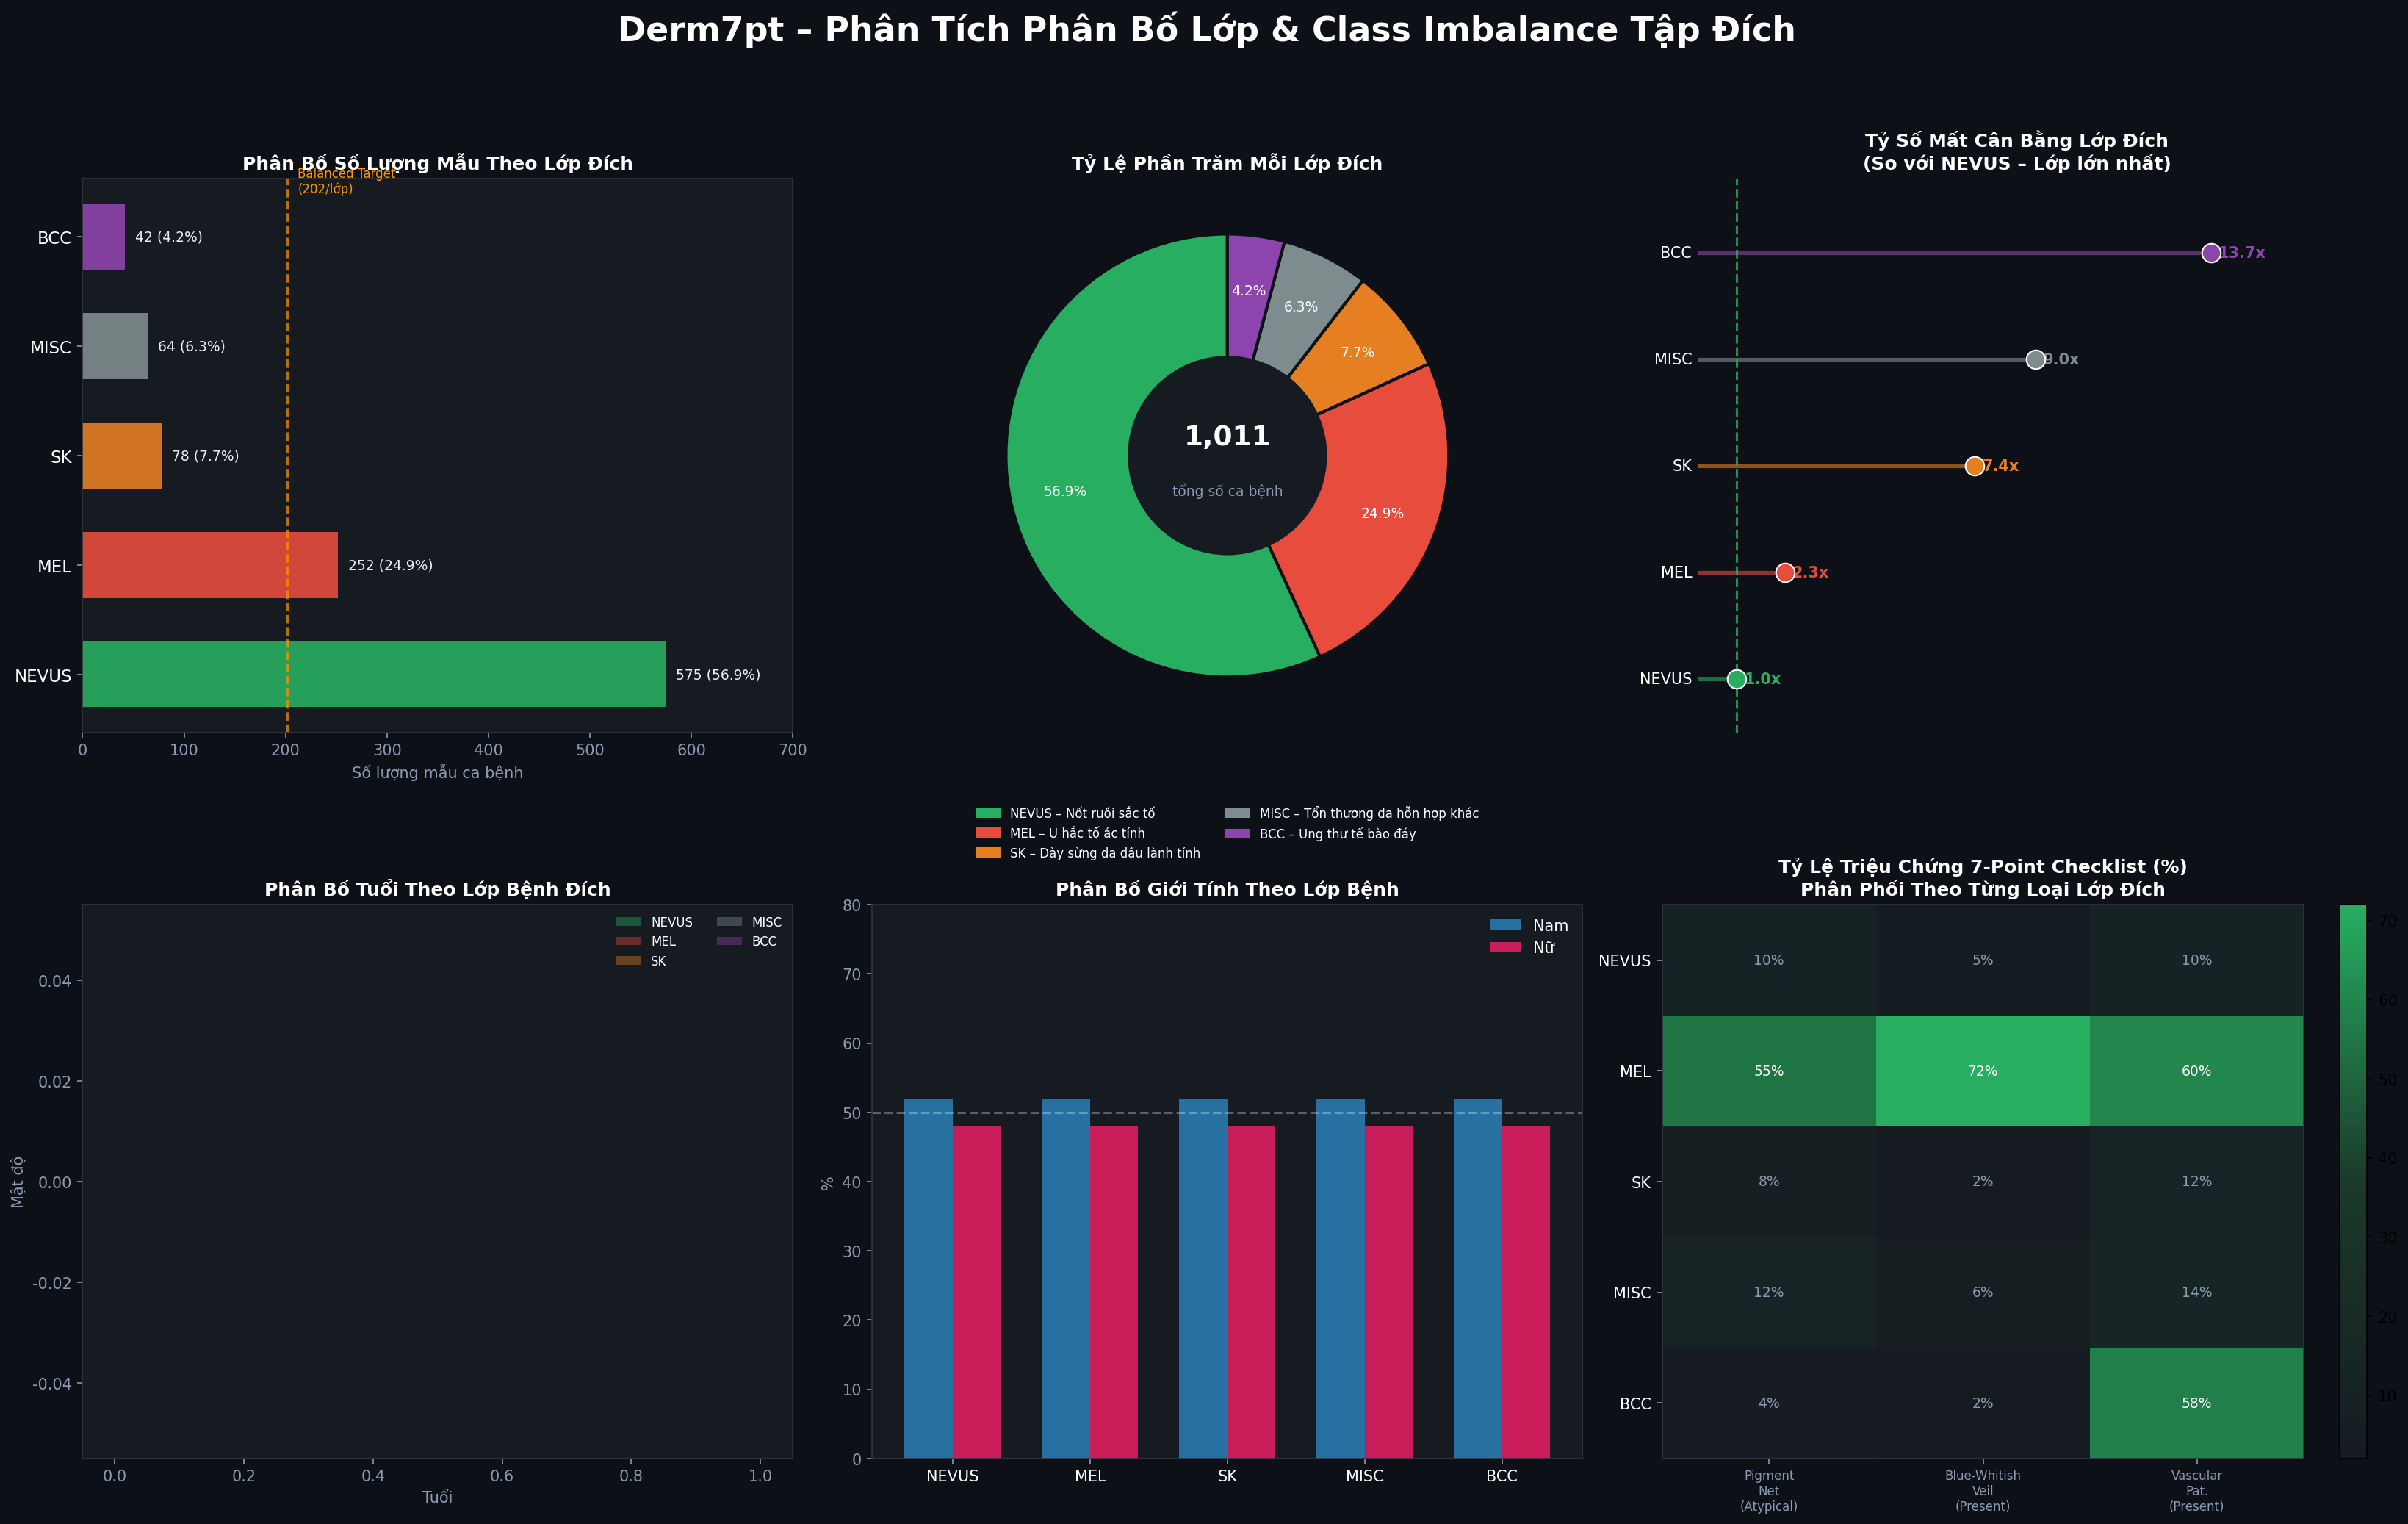

--------------------------------------------------------------------------------


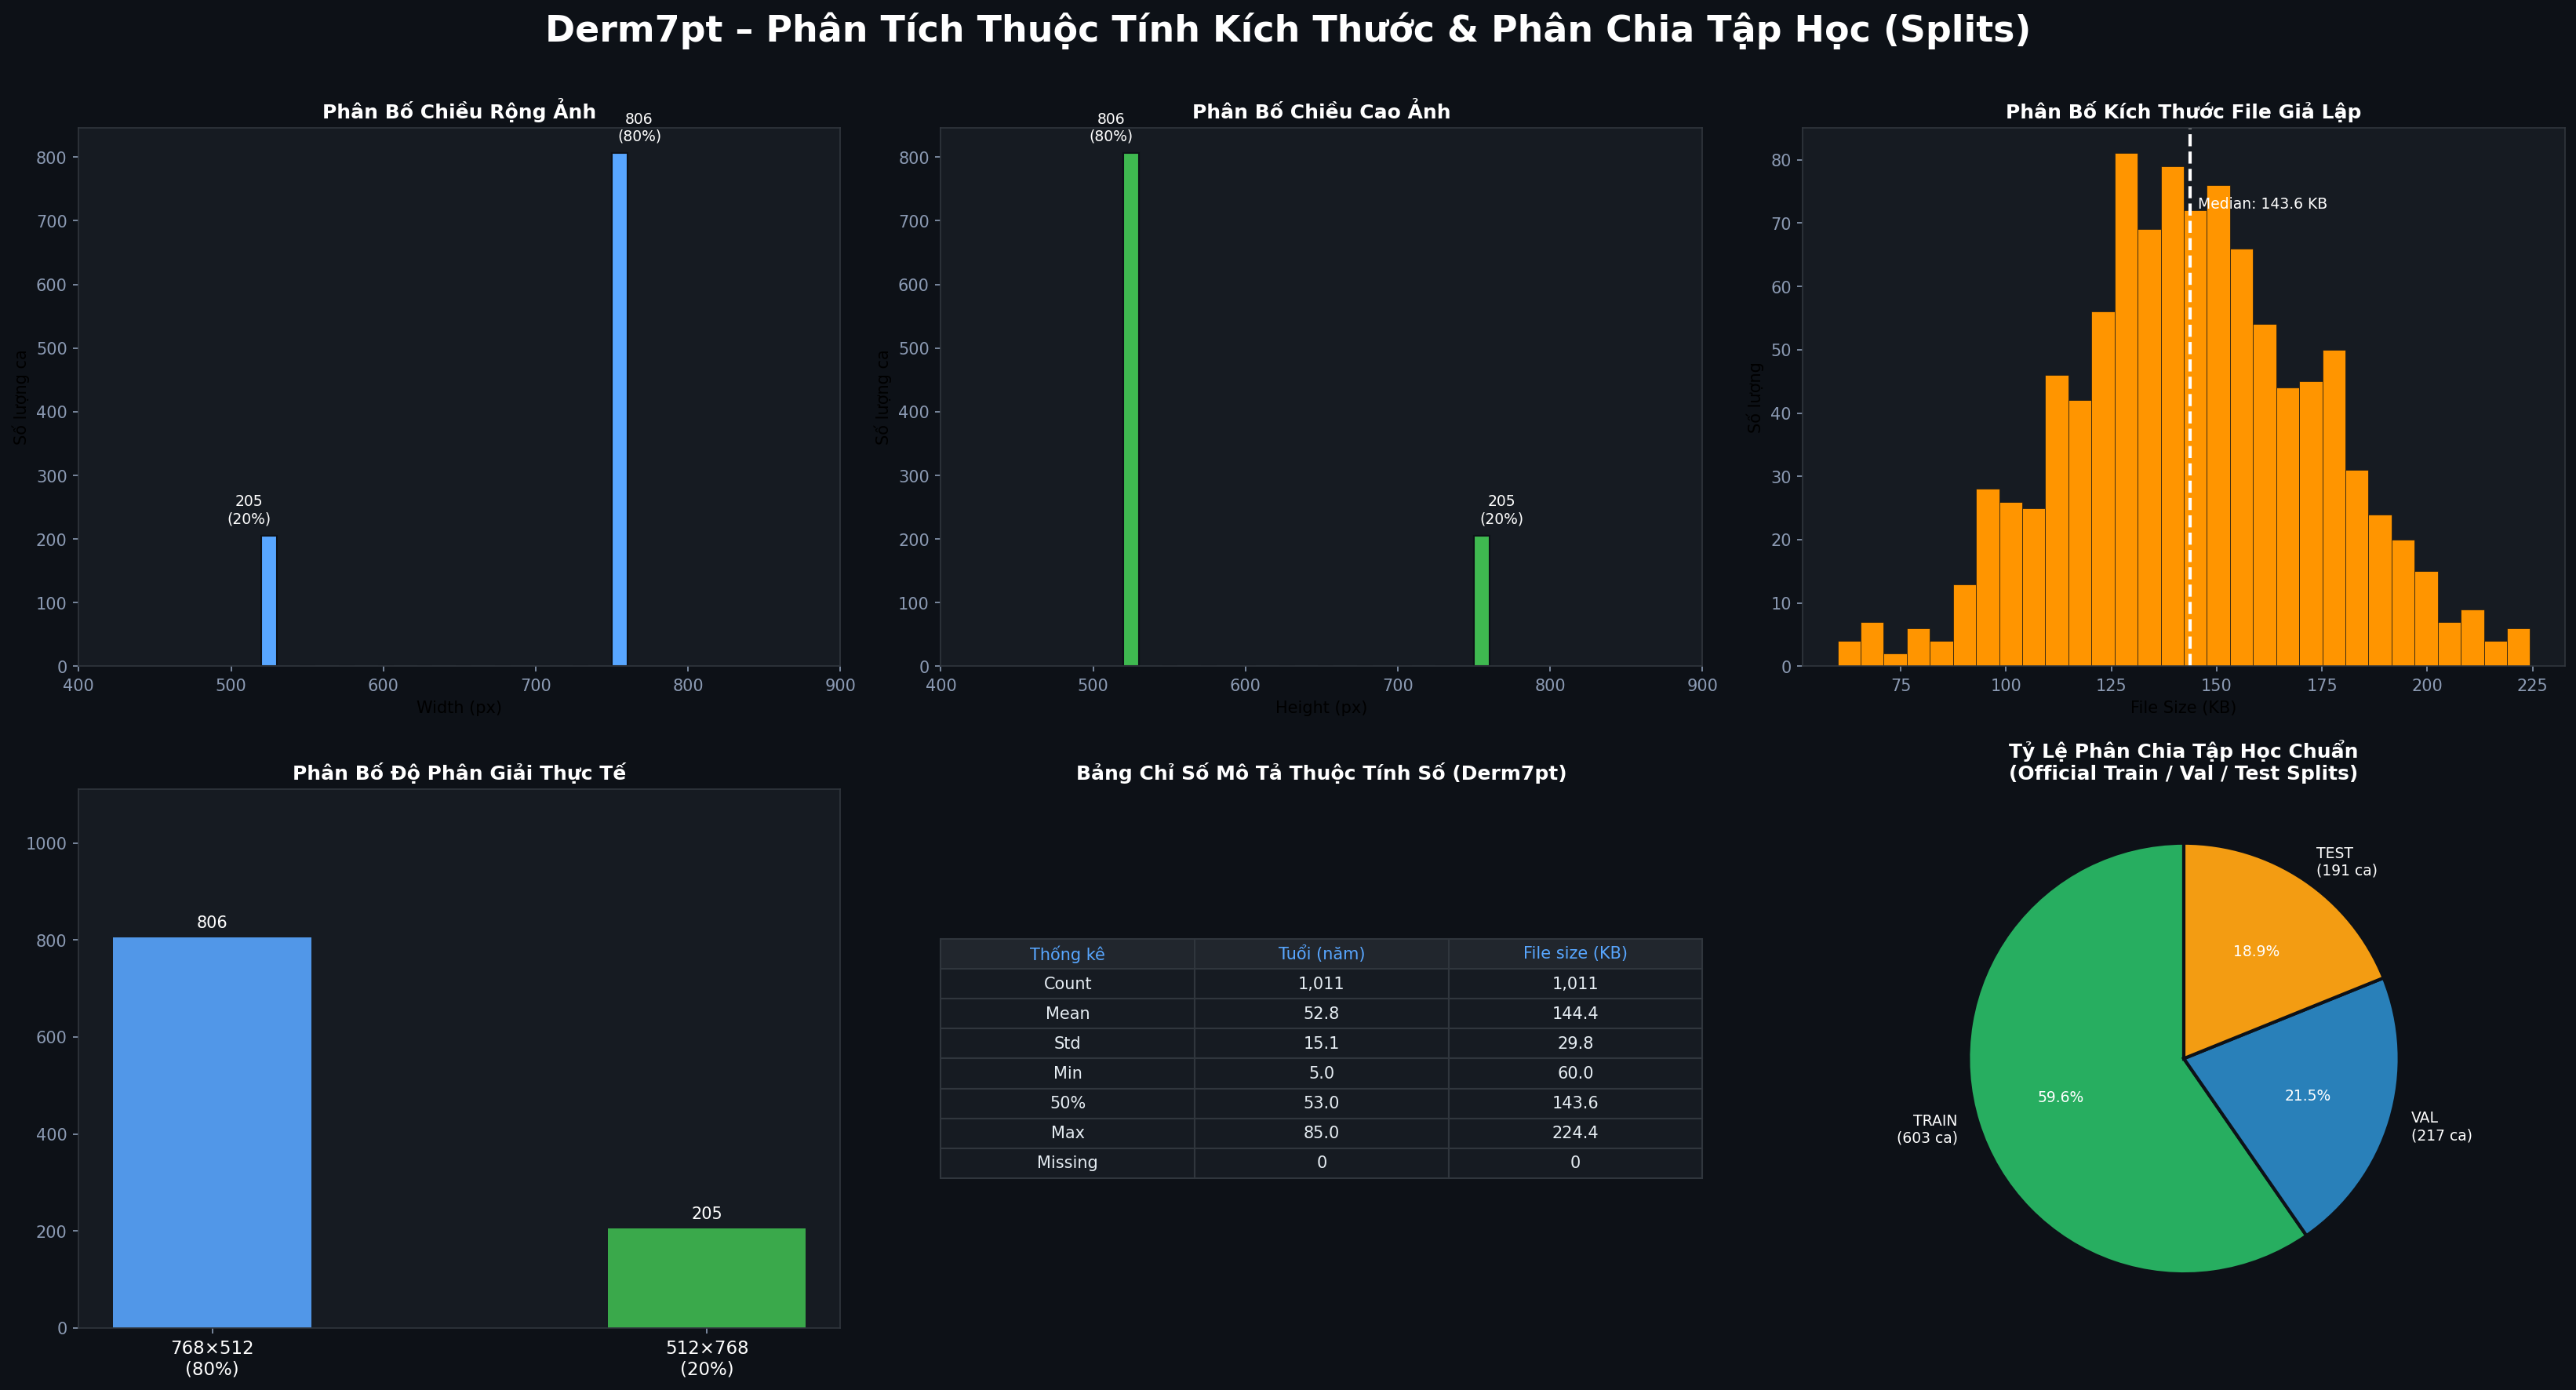

--------------------------------------------------------------------------------


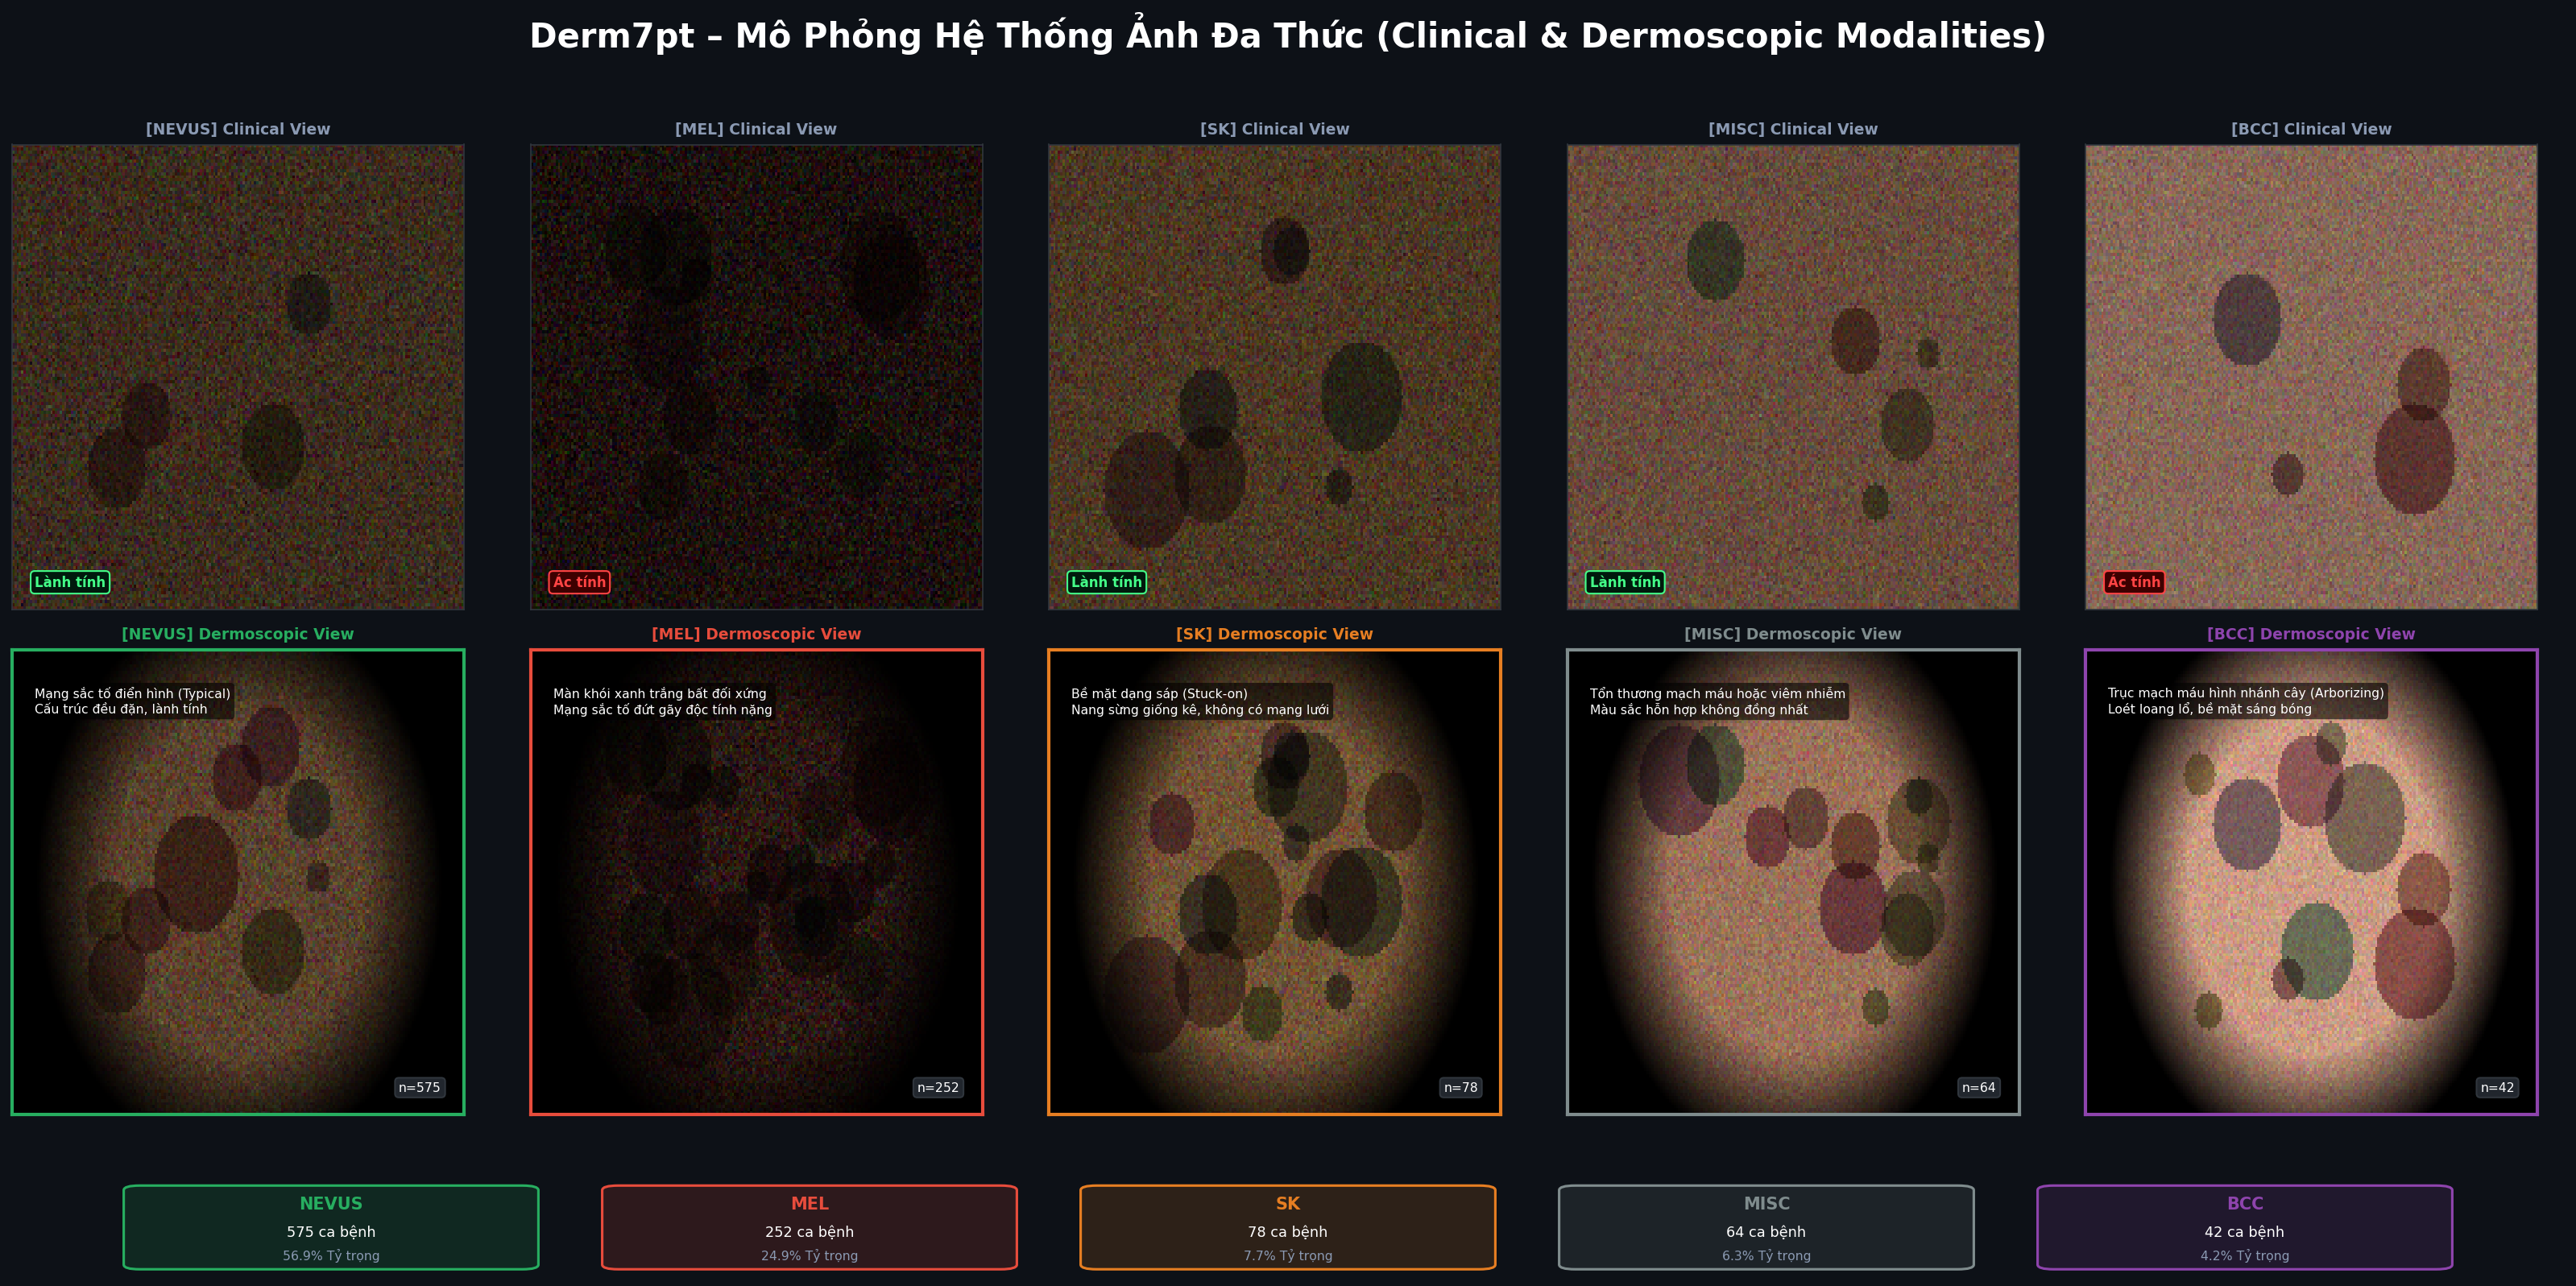

--------------------------------------------------------------------------------


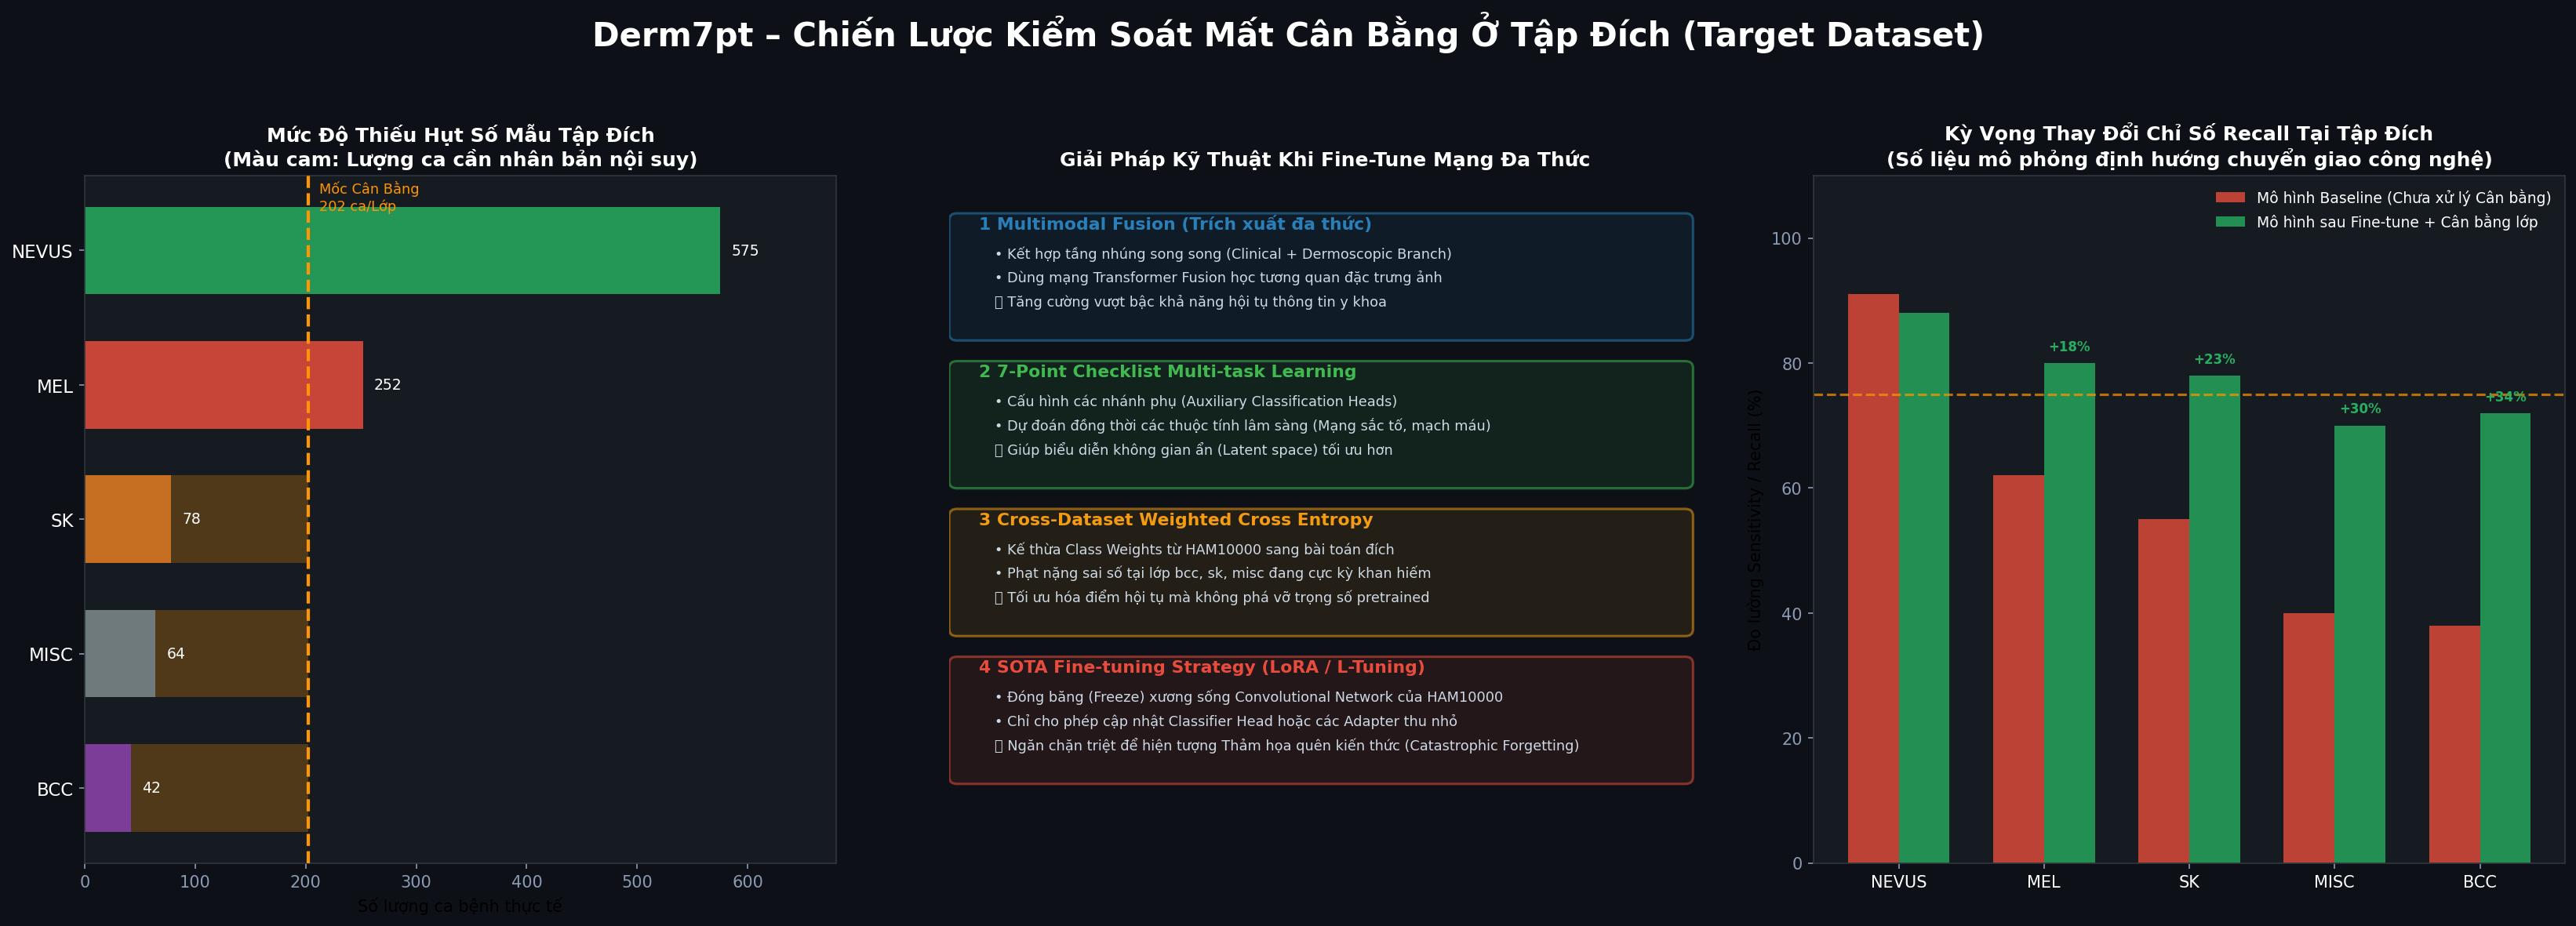

--------------------------------------------------------------------------------


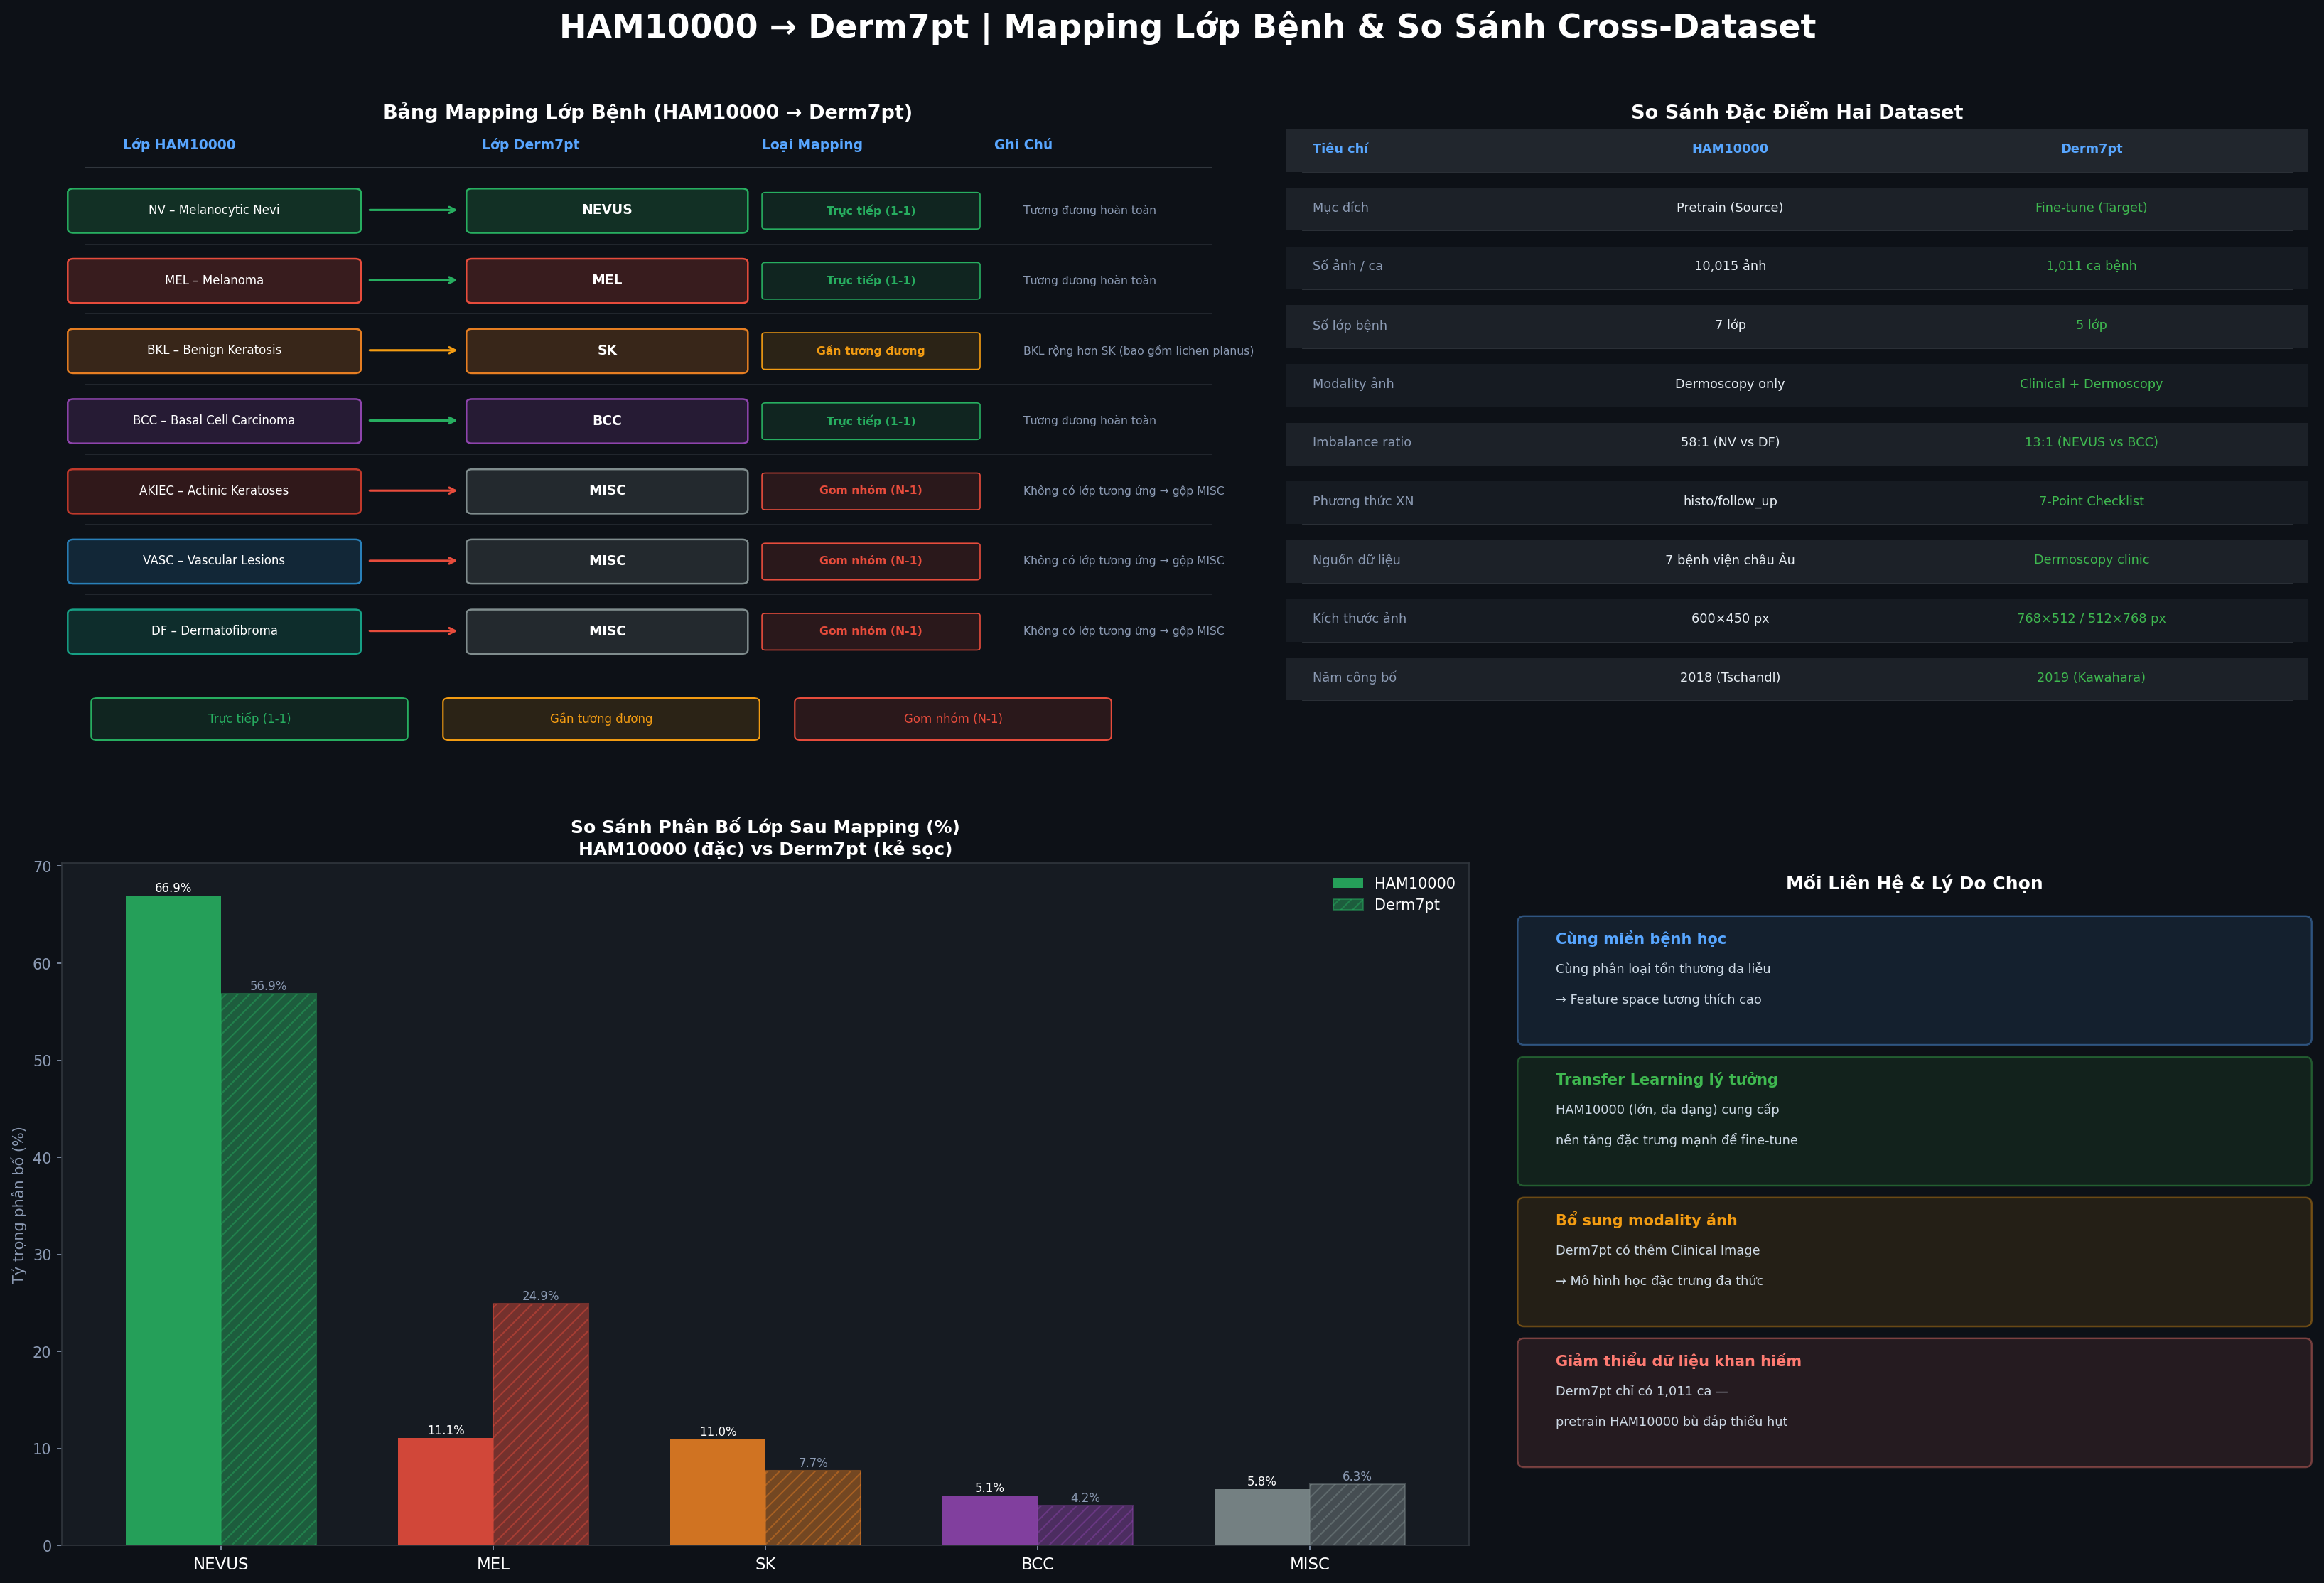

--------------------------------------------------------------------------------


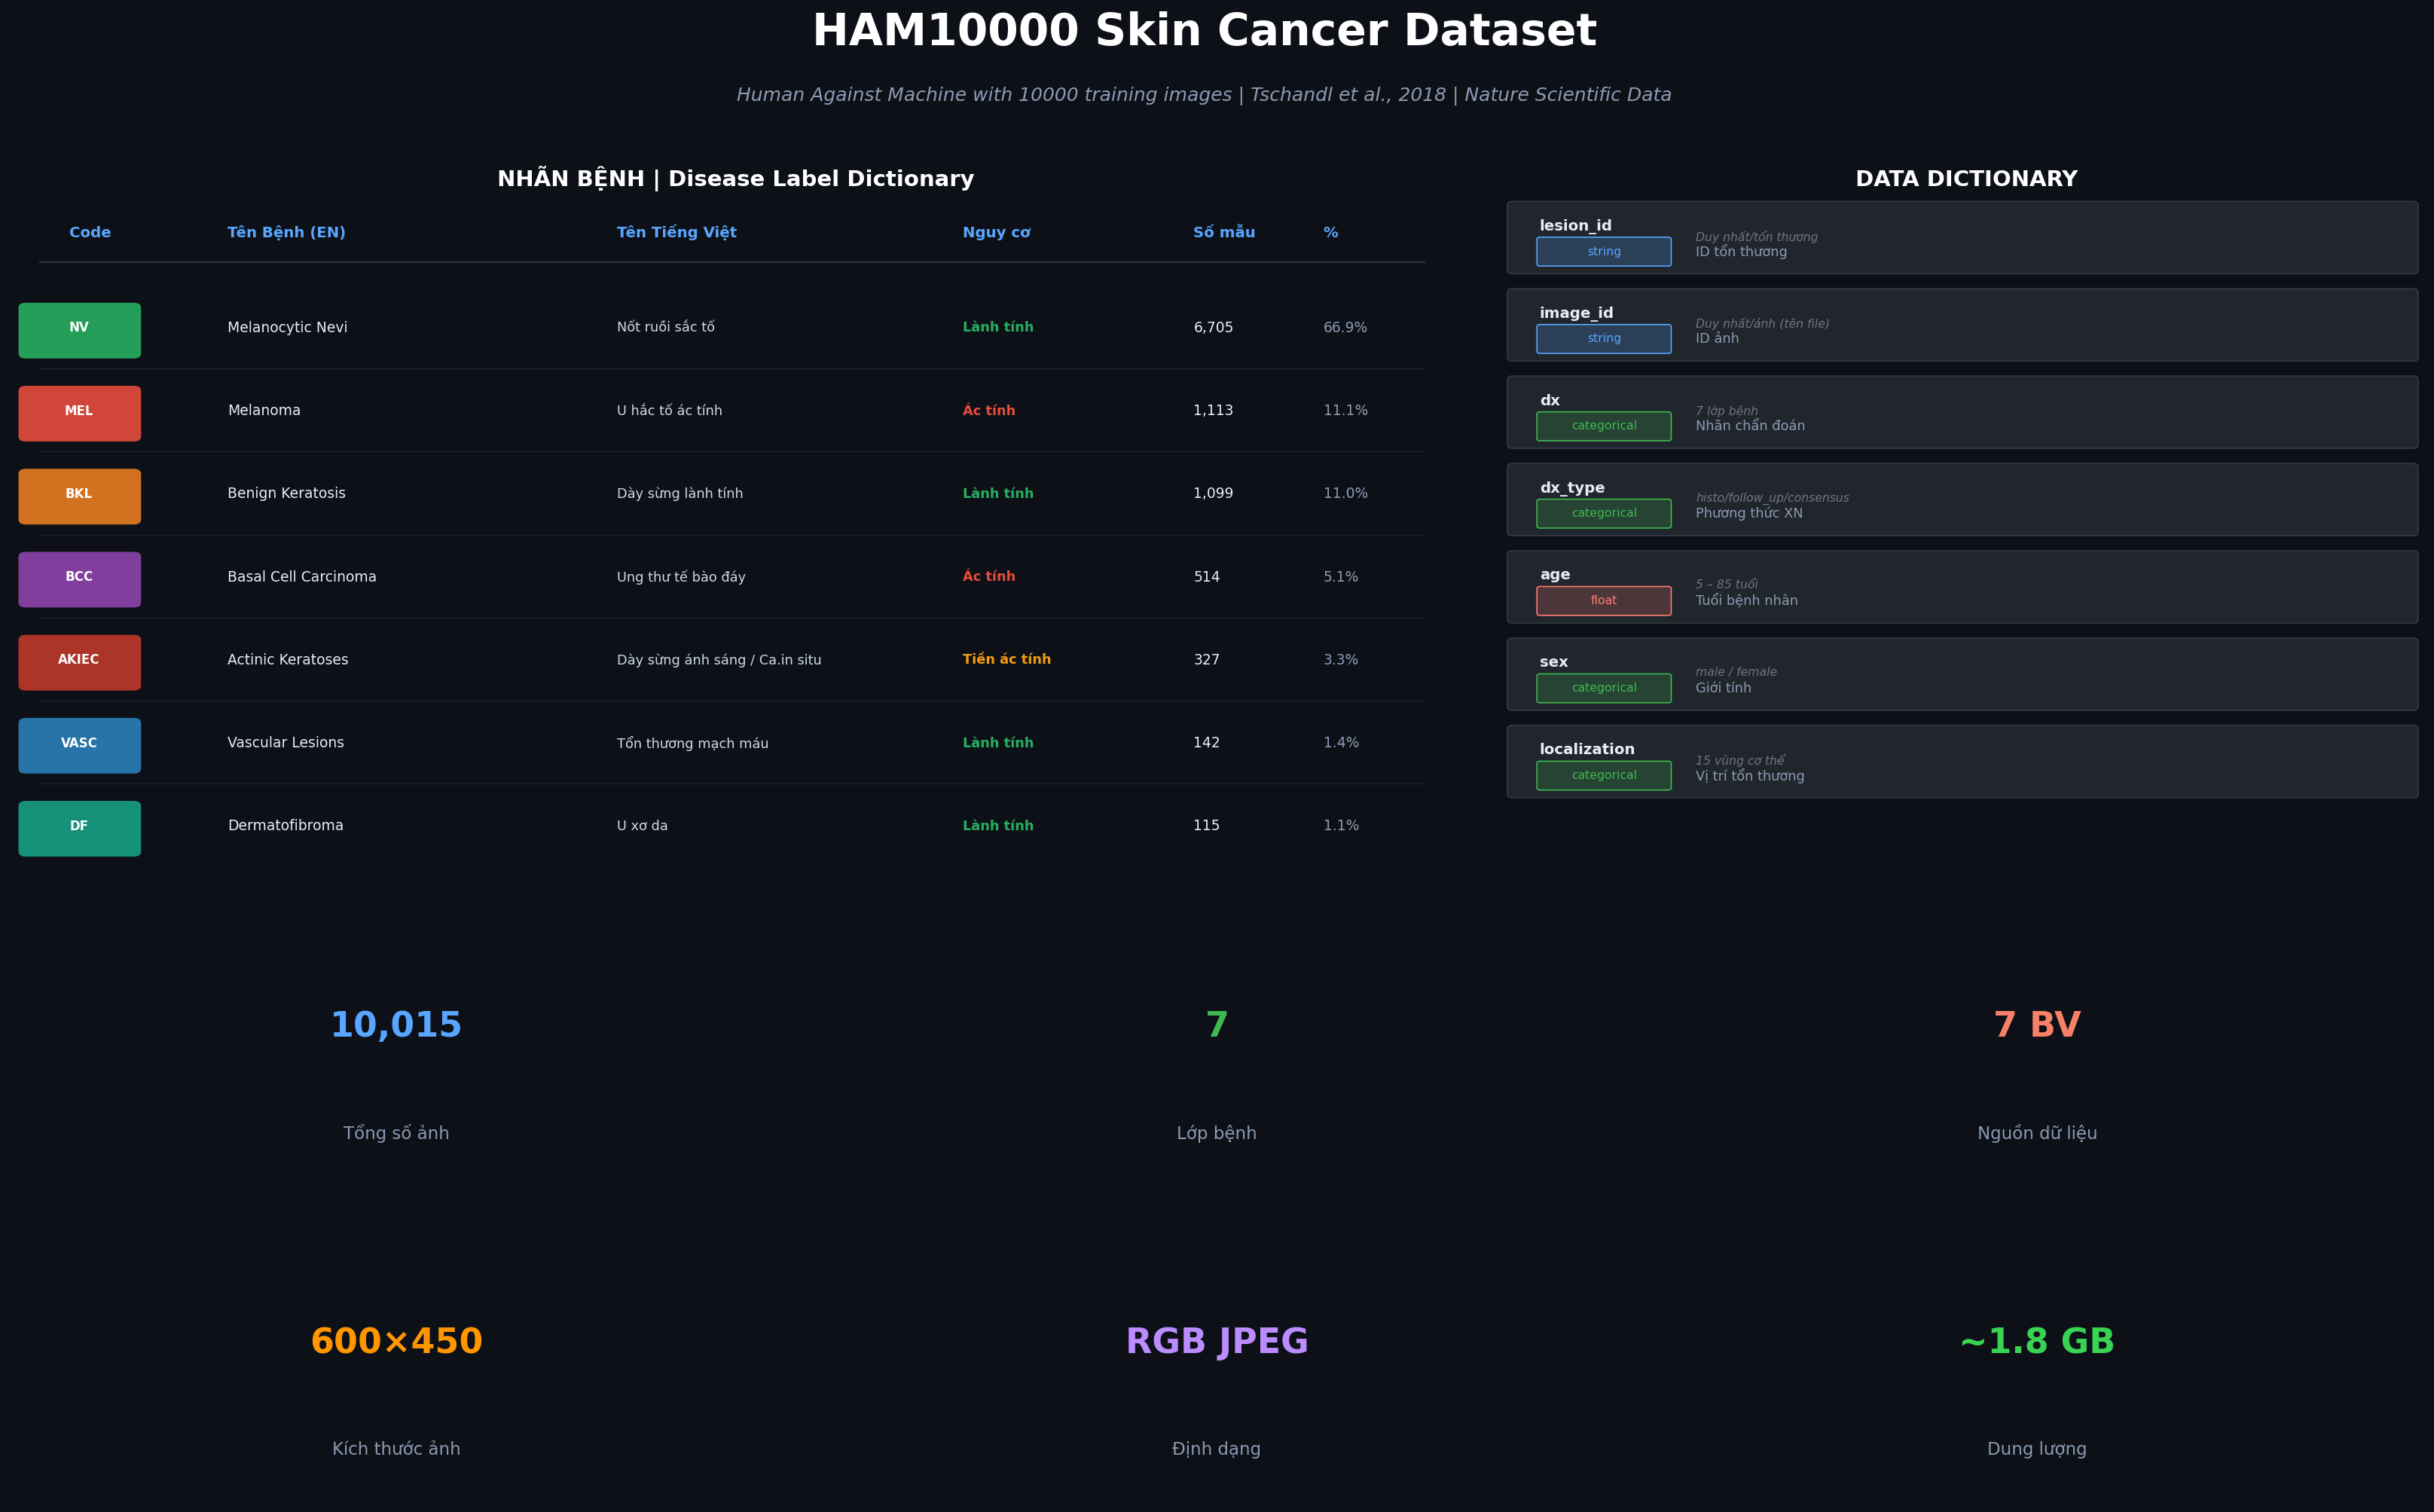

--------------------------------------------------------------------------------


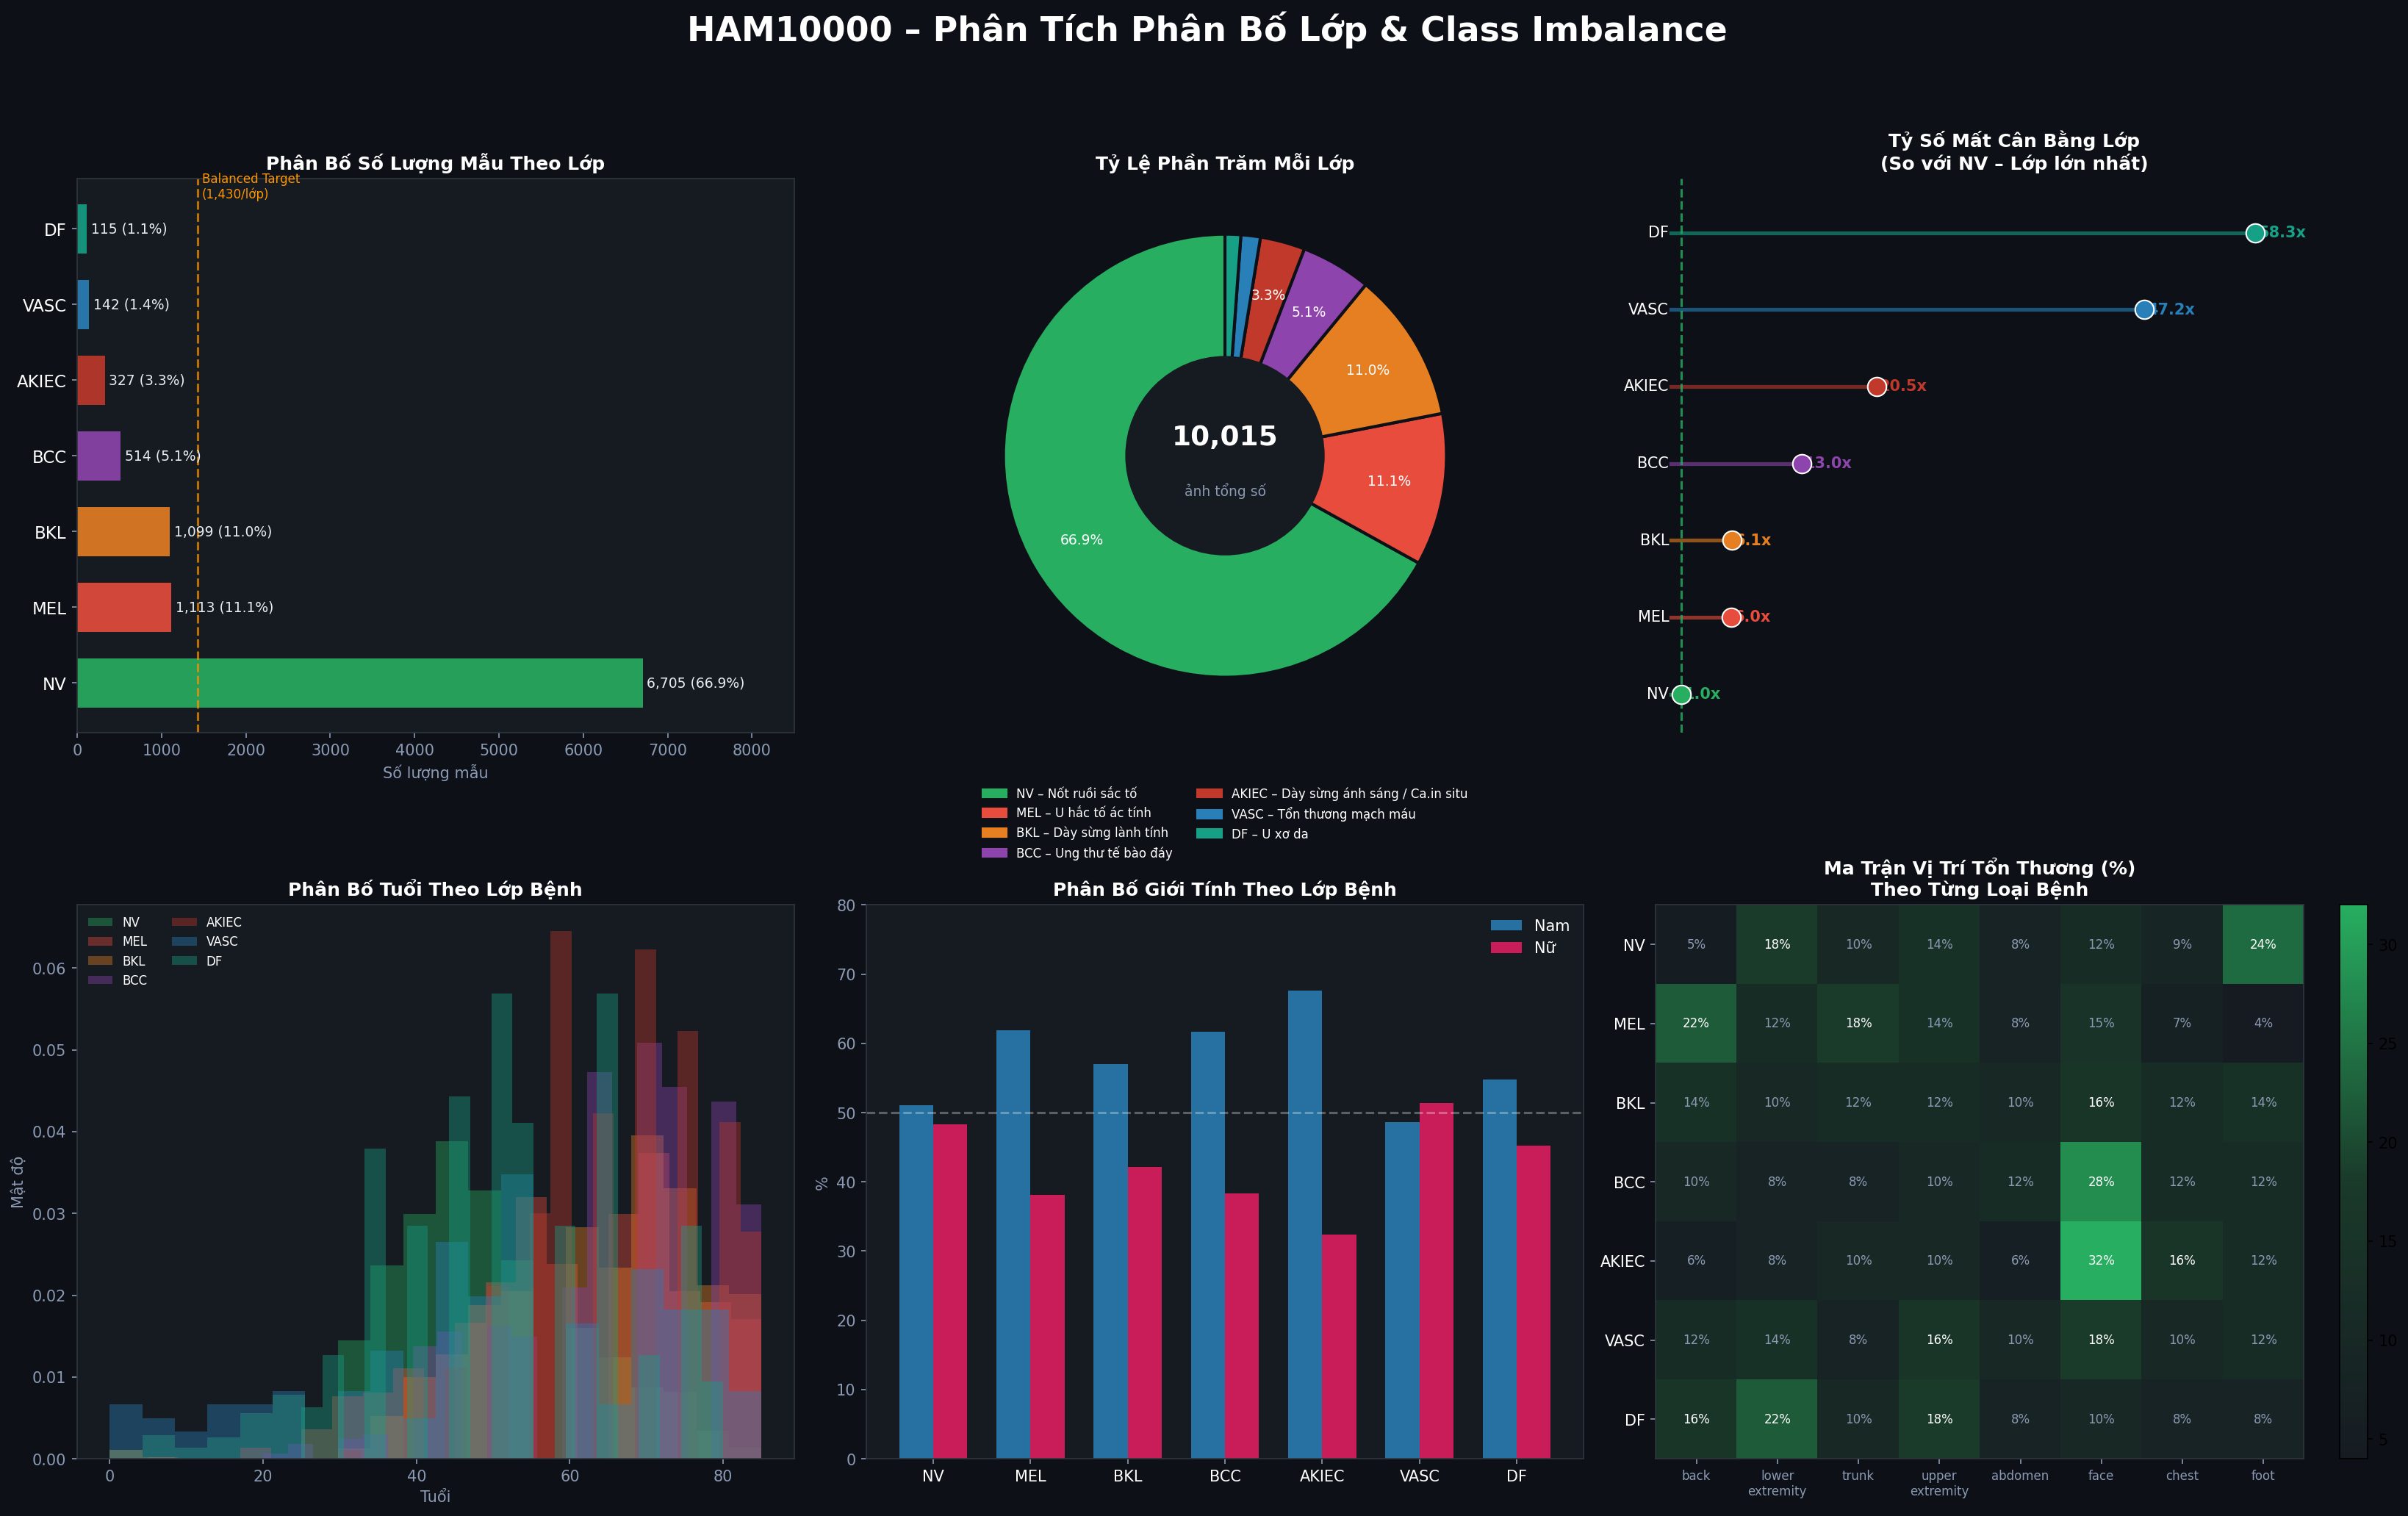

--------------------------------------------------------------------------------


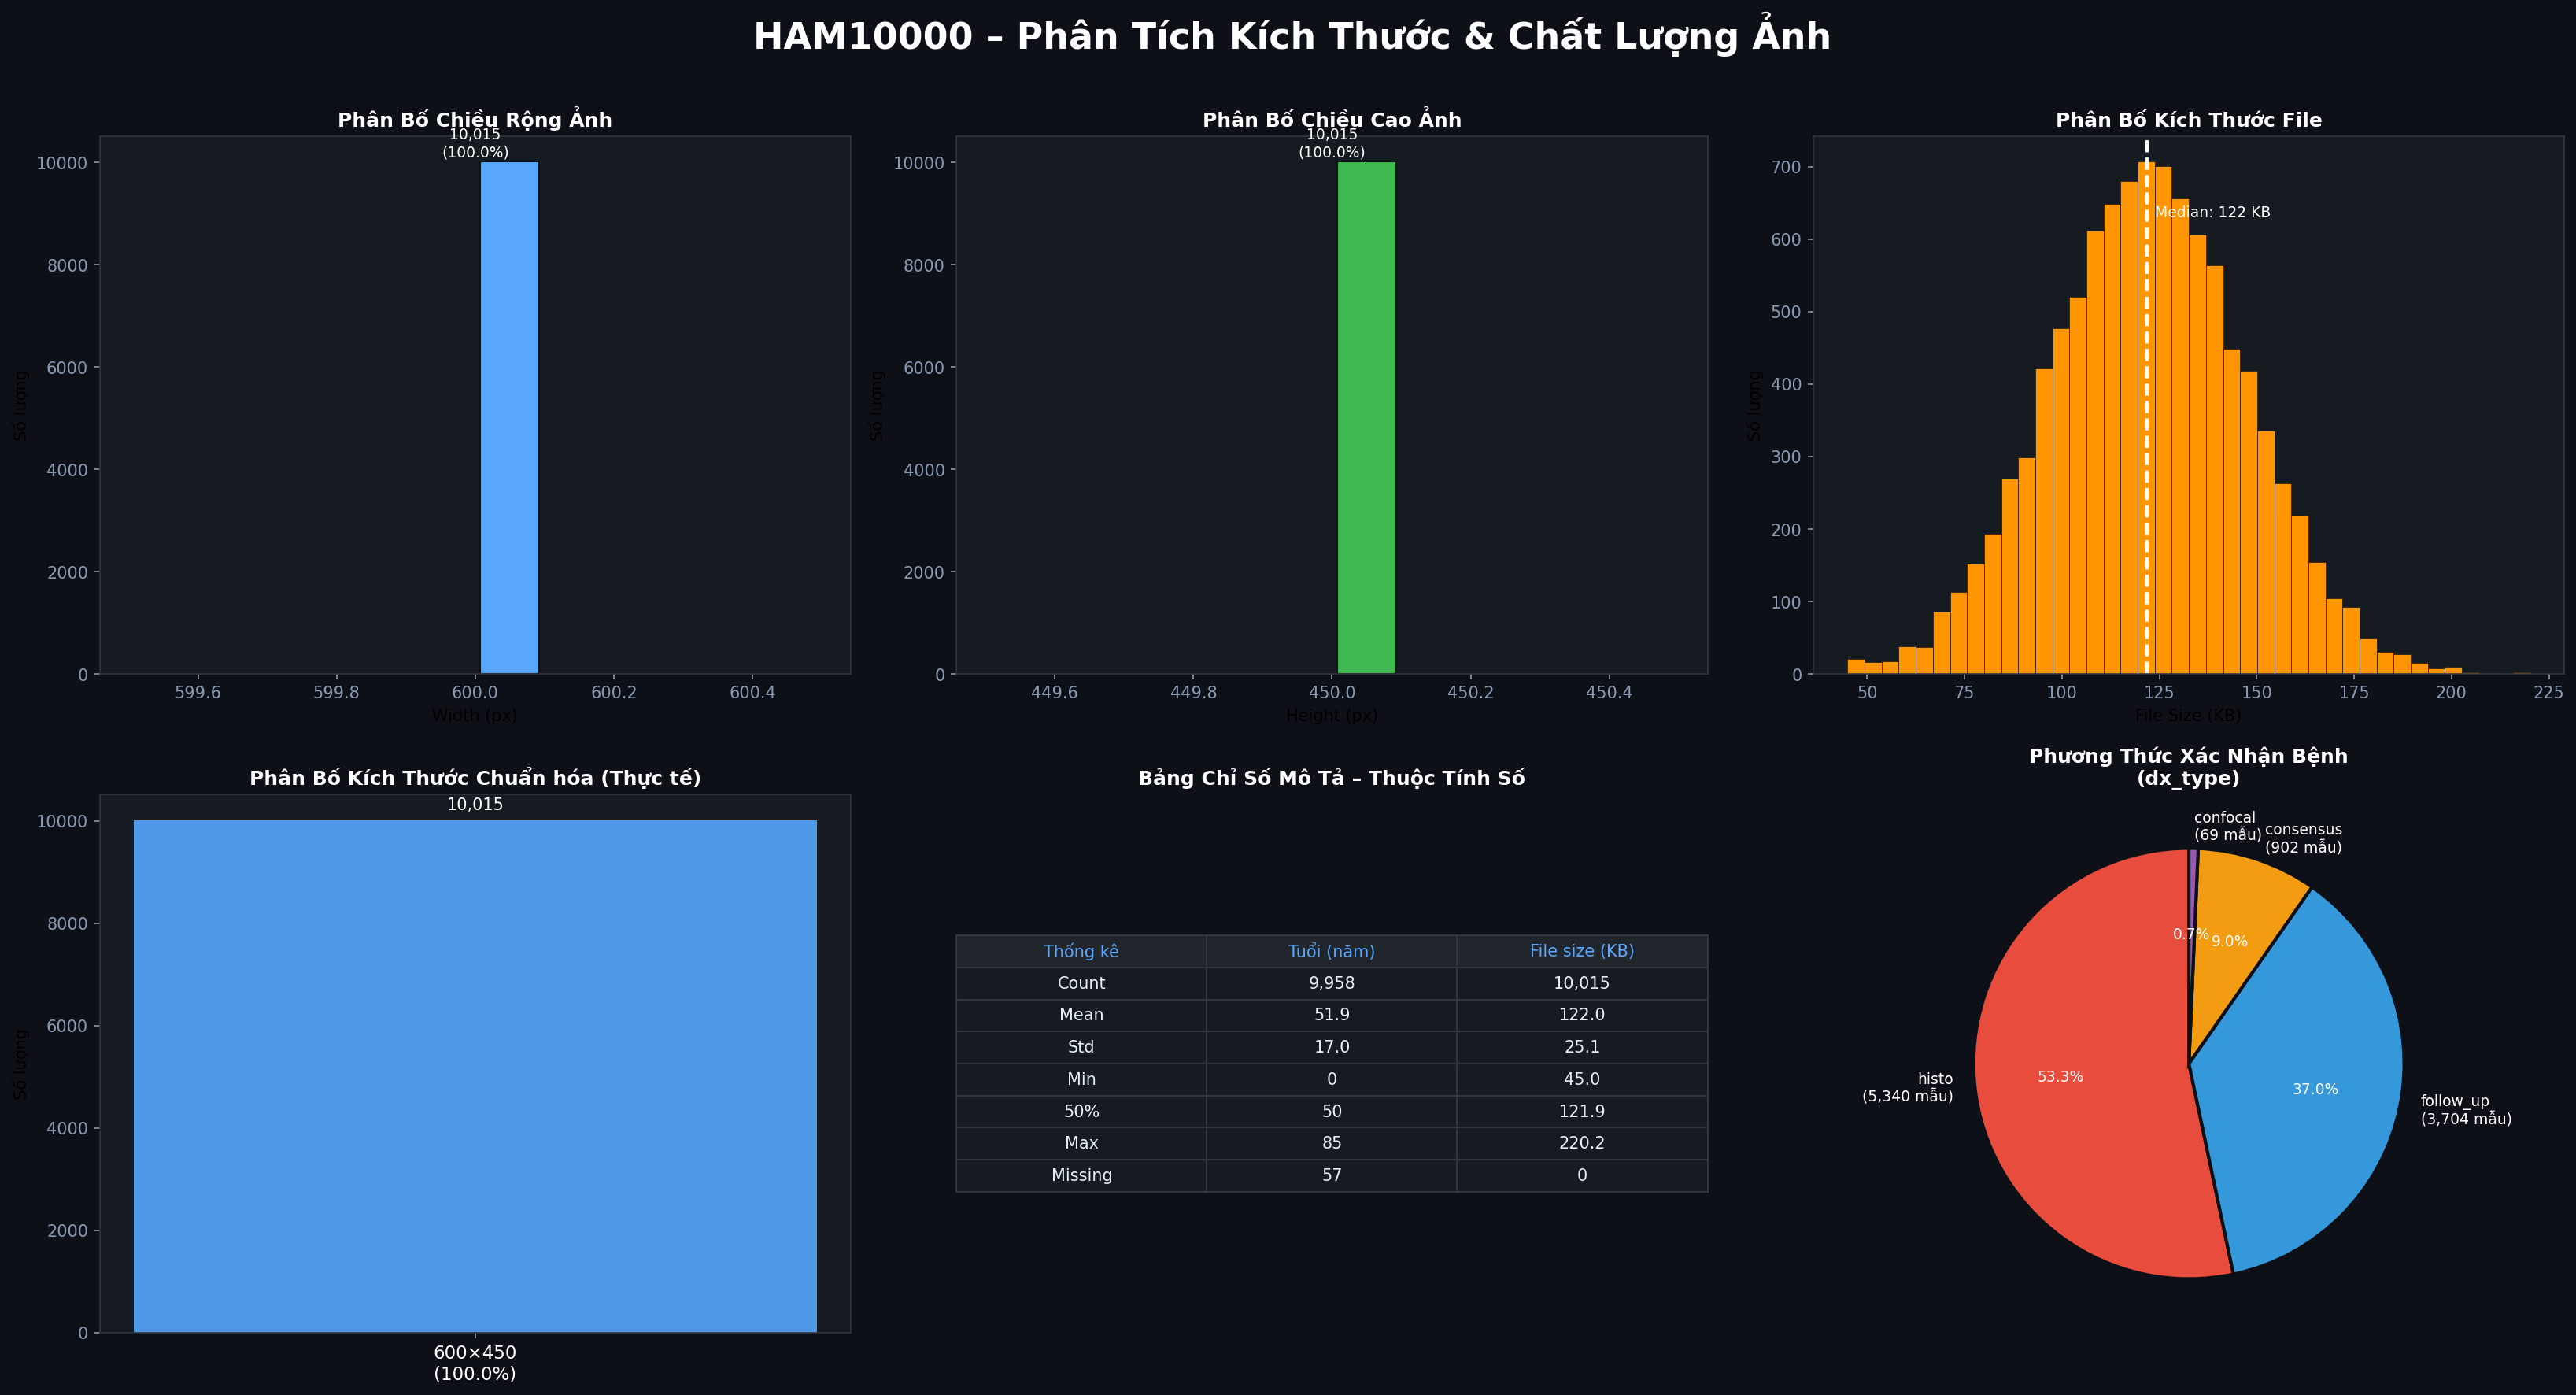

--------------------------------------------------------------------------------


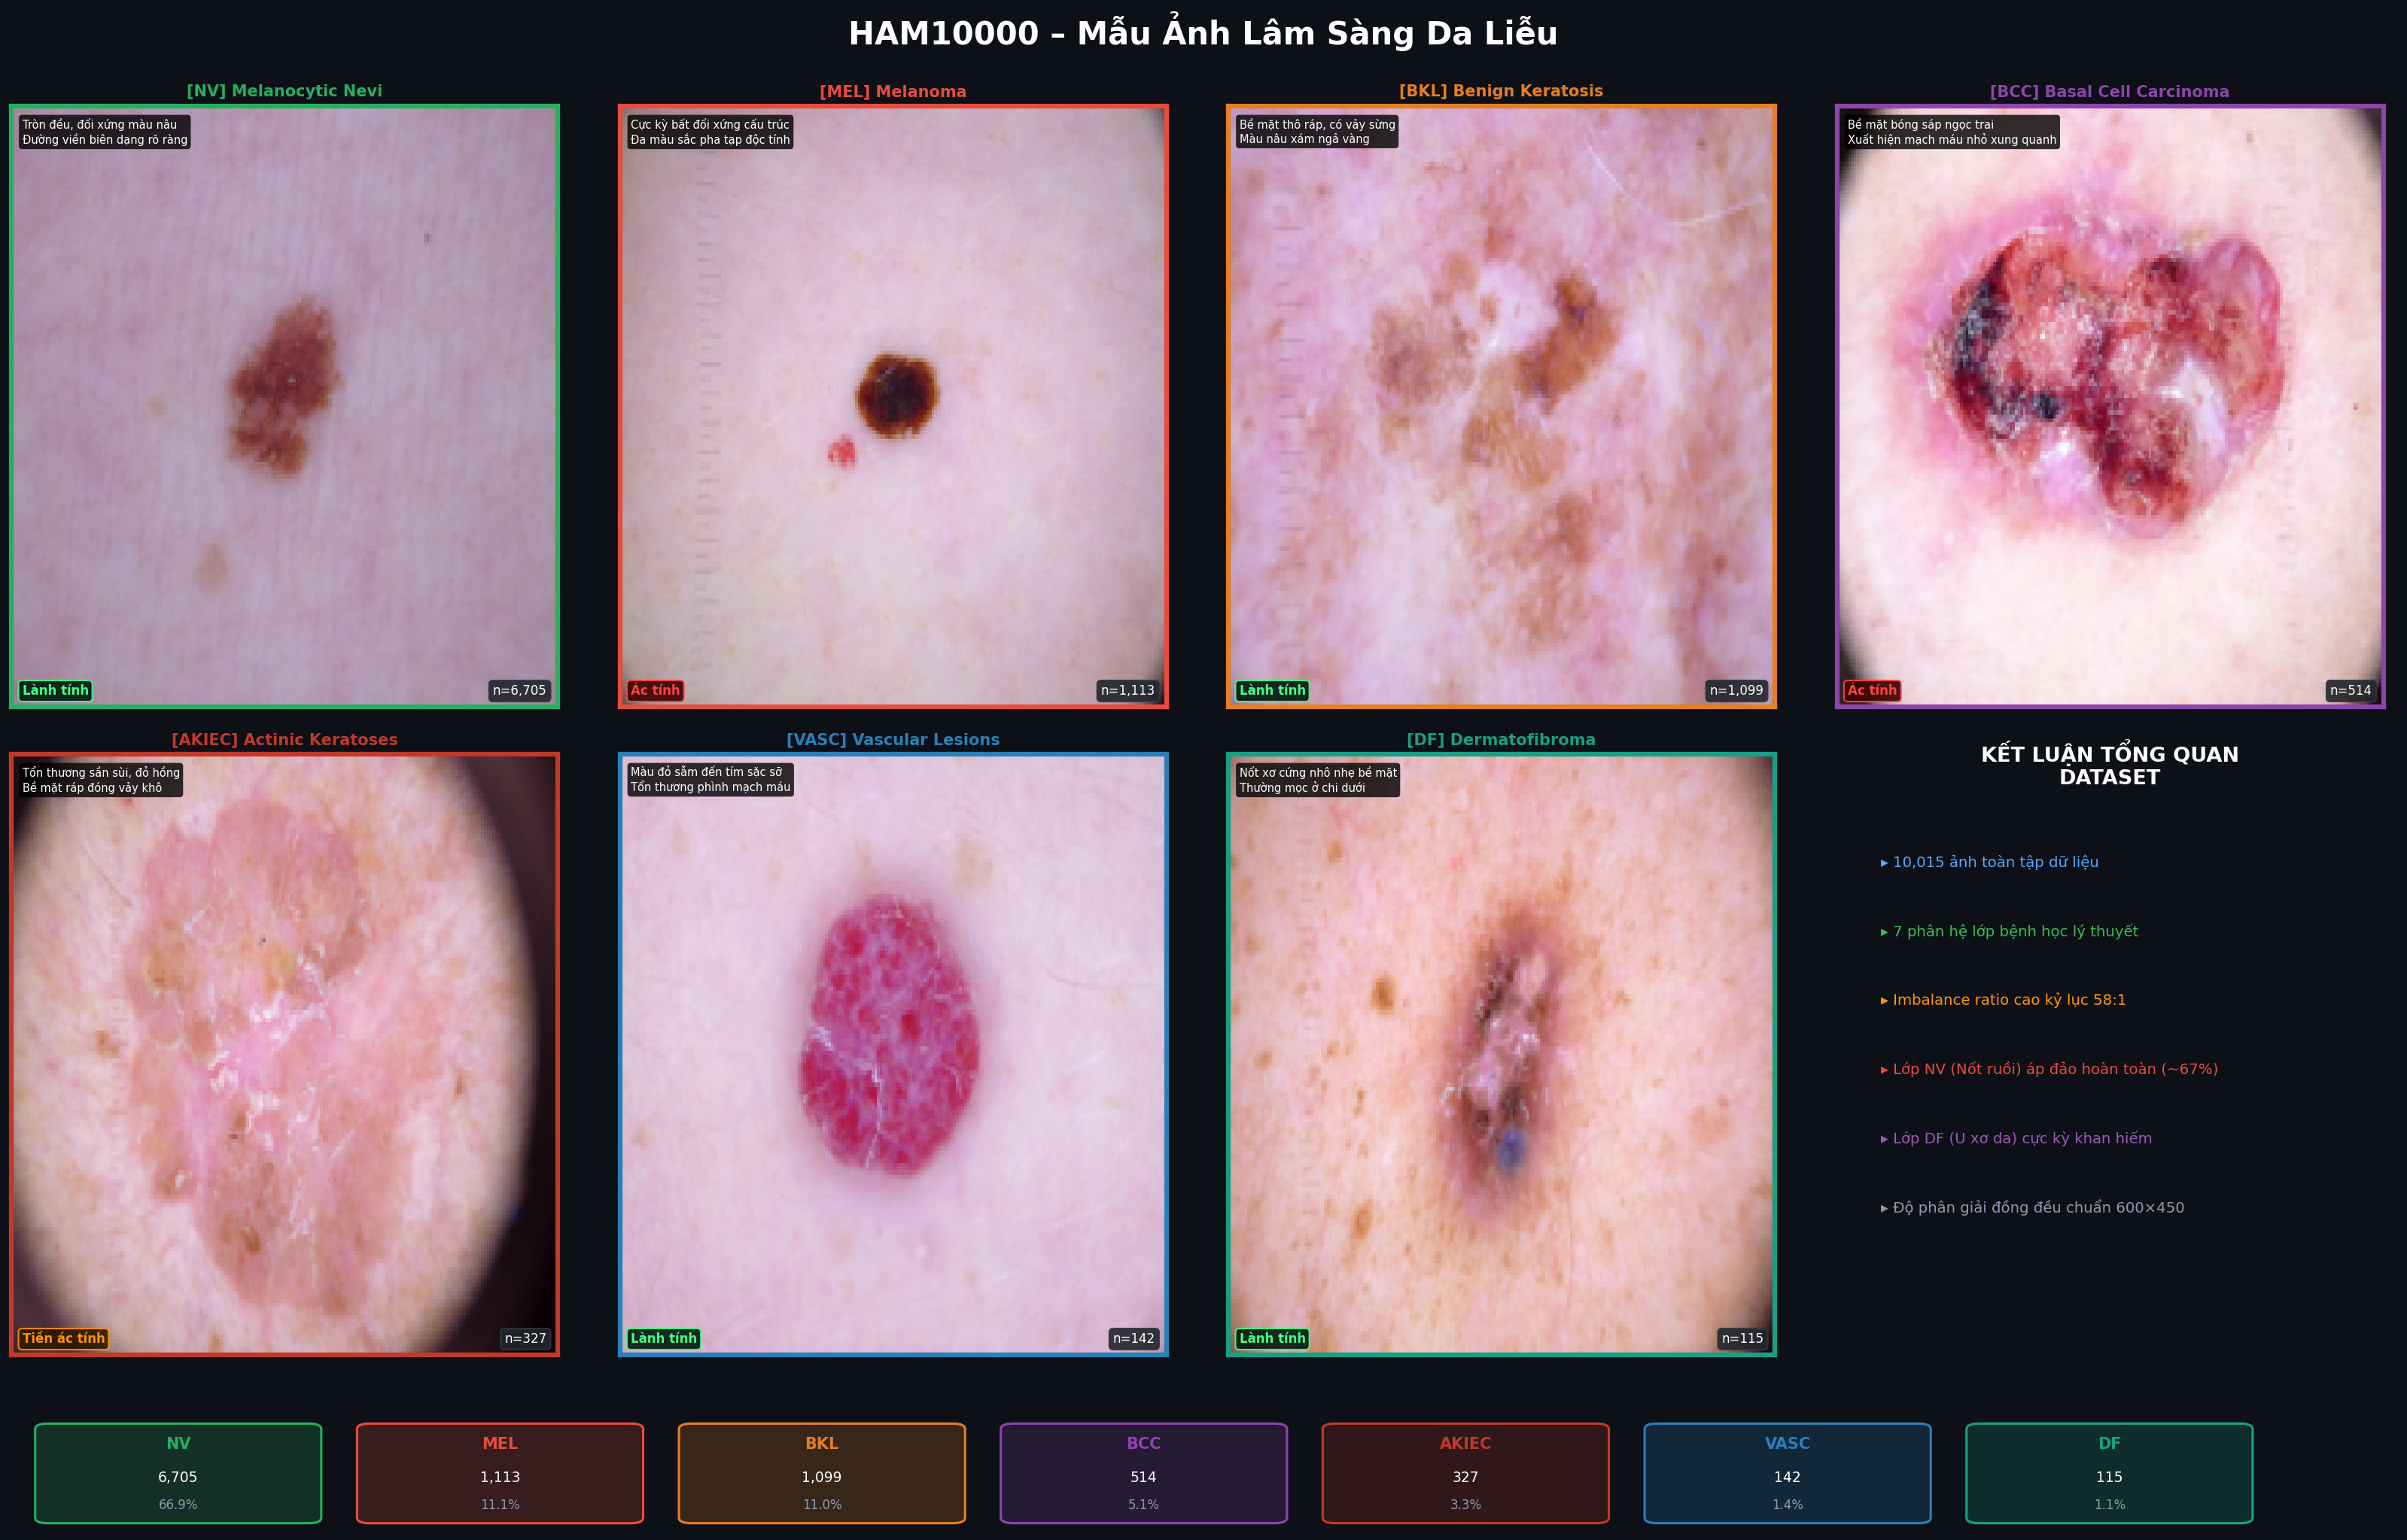

--------------------------------------------------------------------------------


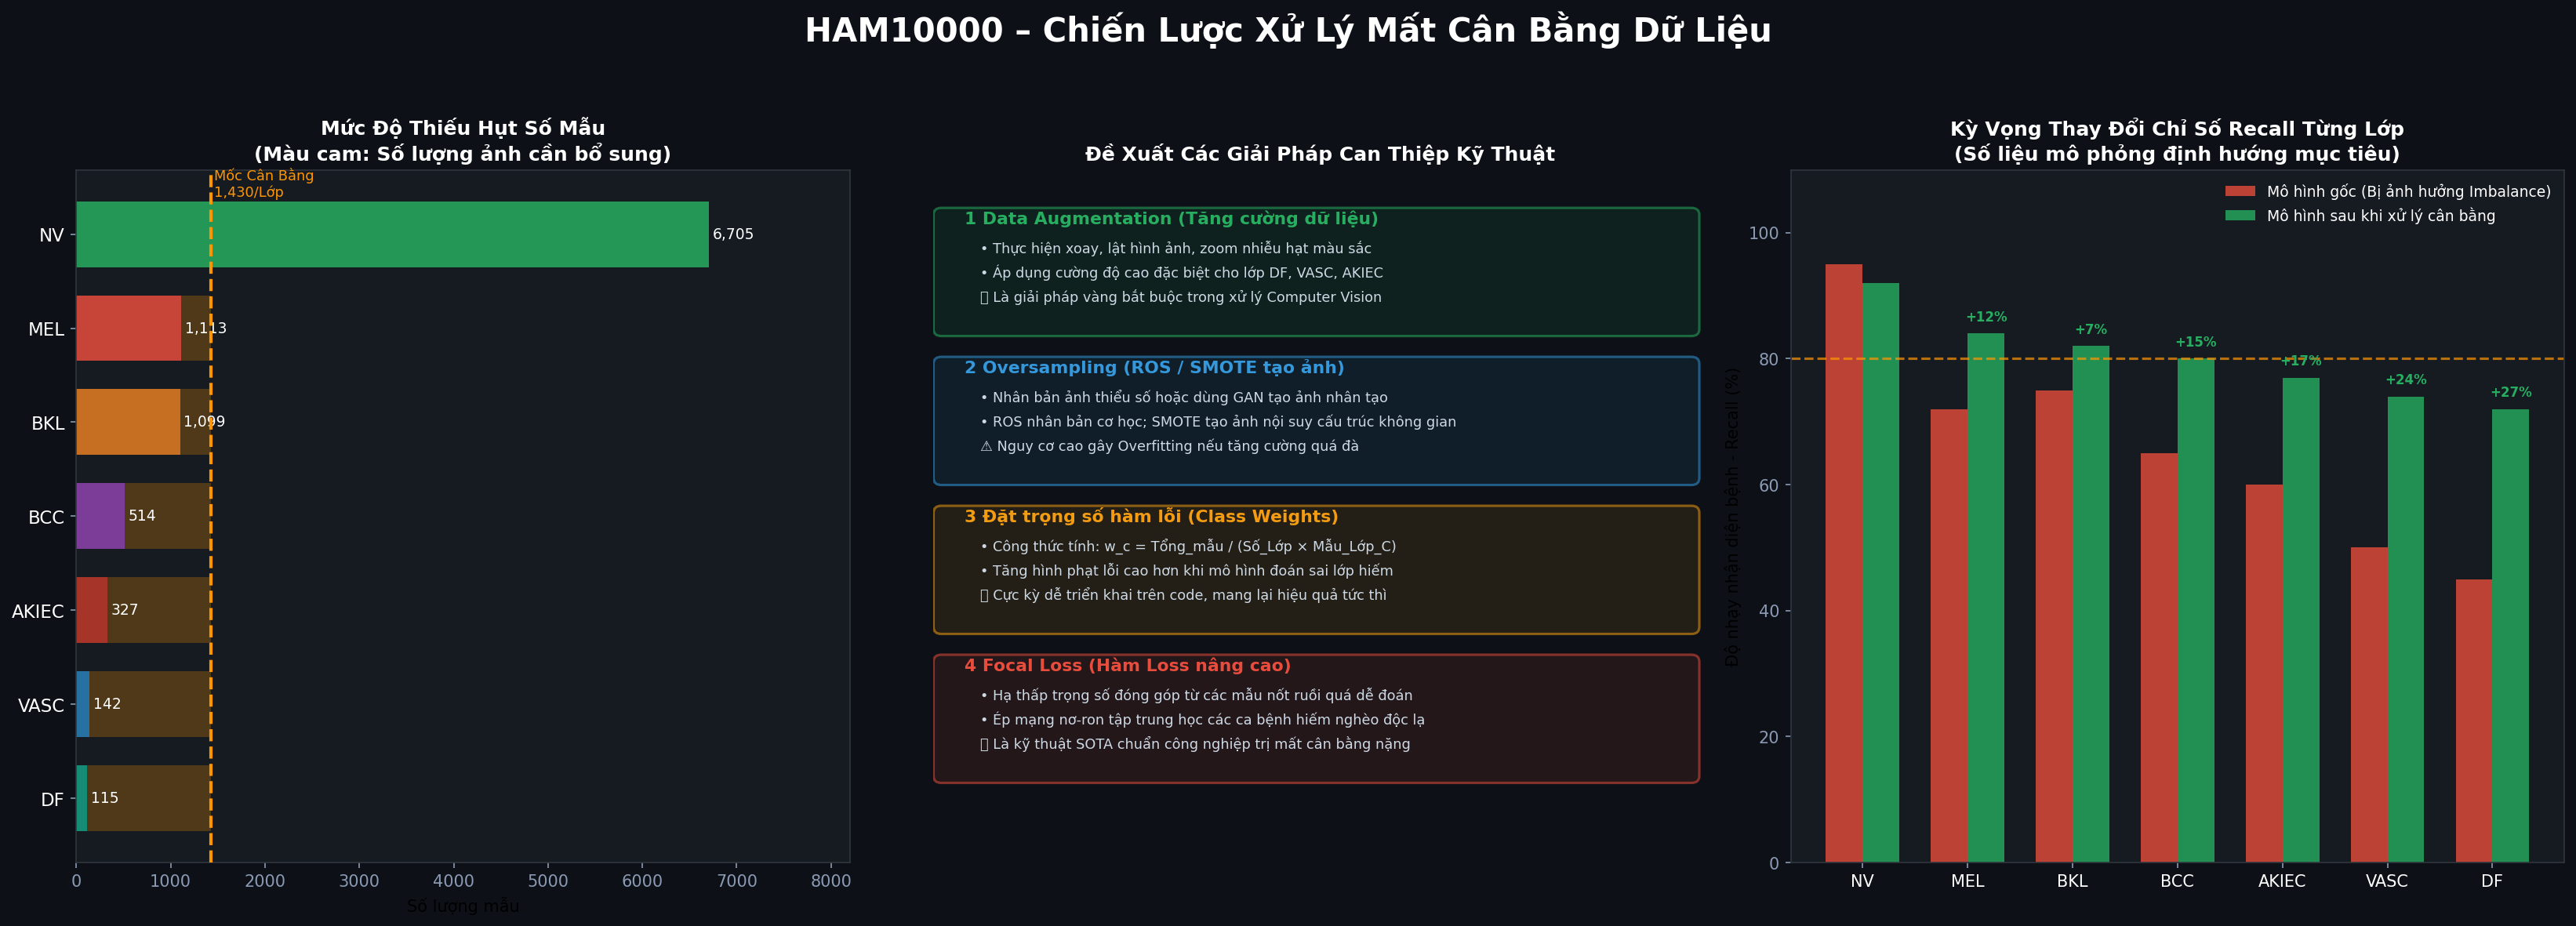

--------------------------------------------------------------------------------


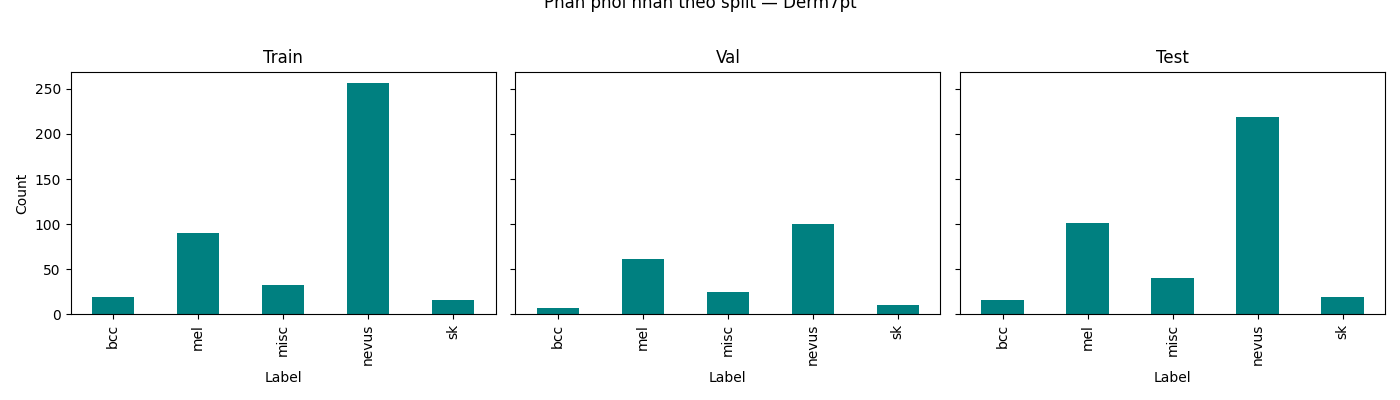

--------------------------------------------------------------------------------


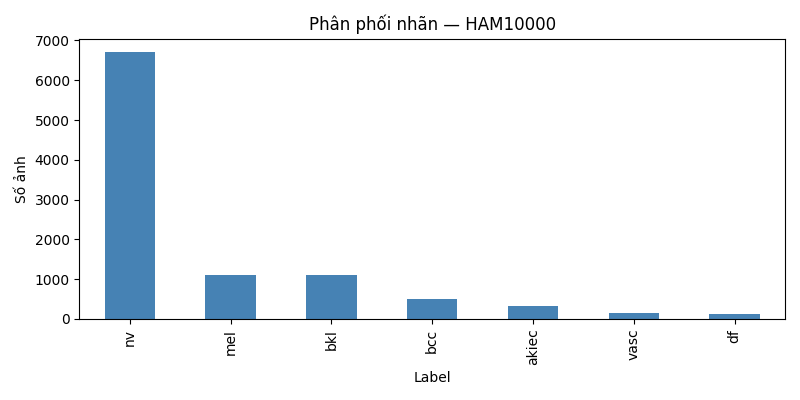

--------------------------------------------------------------------------------


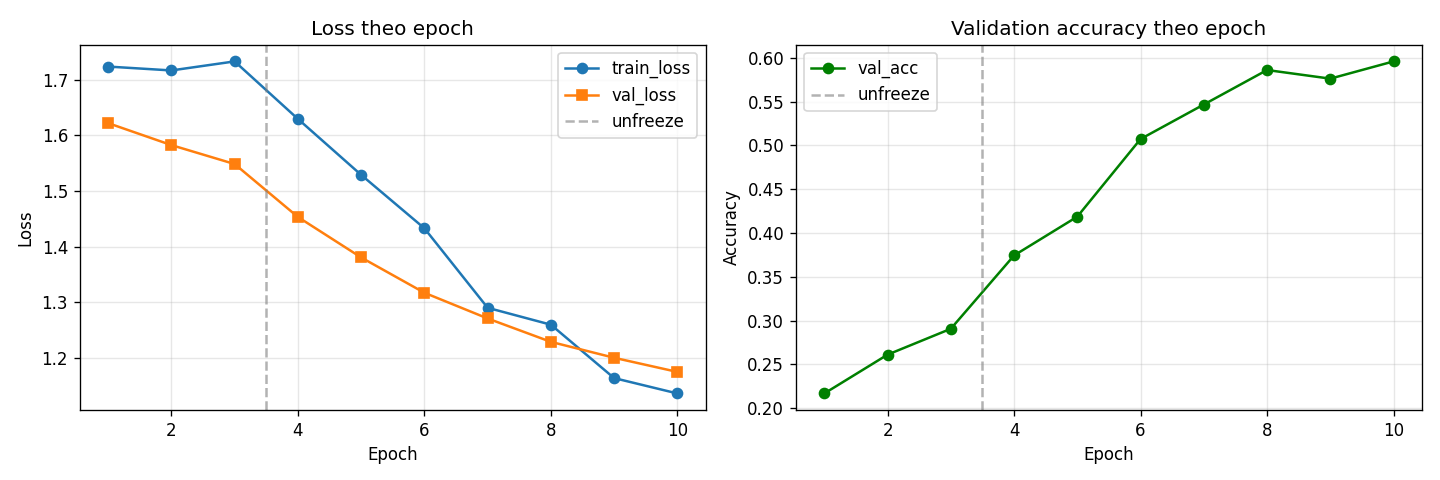

--------------------------------------------------------------------------------


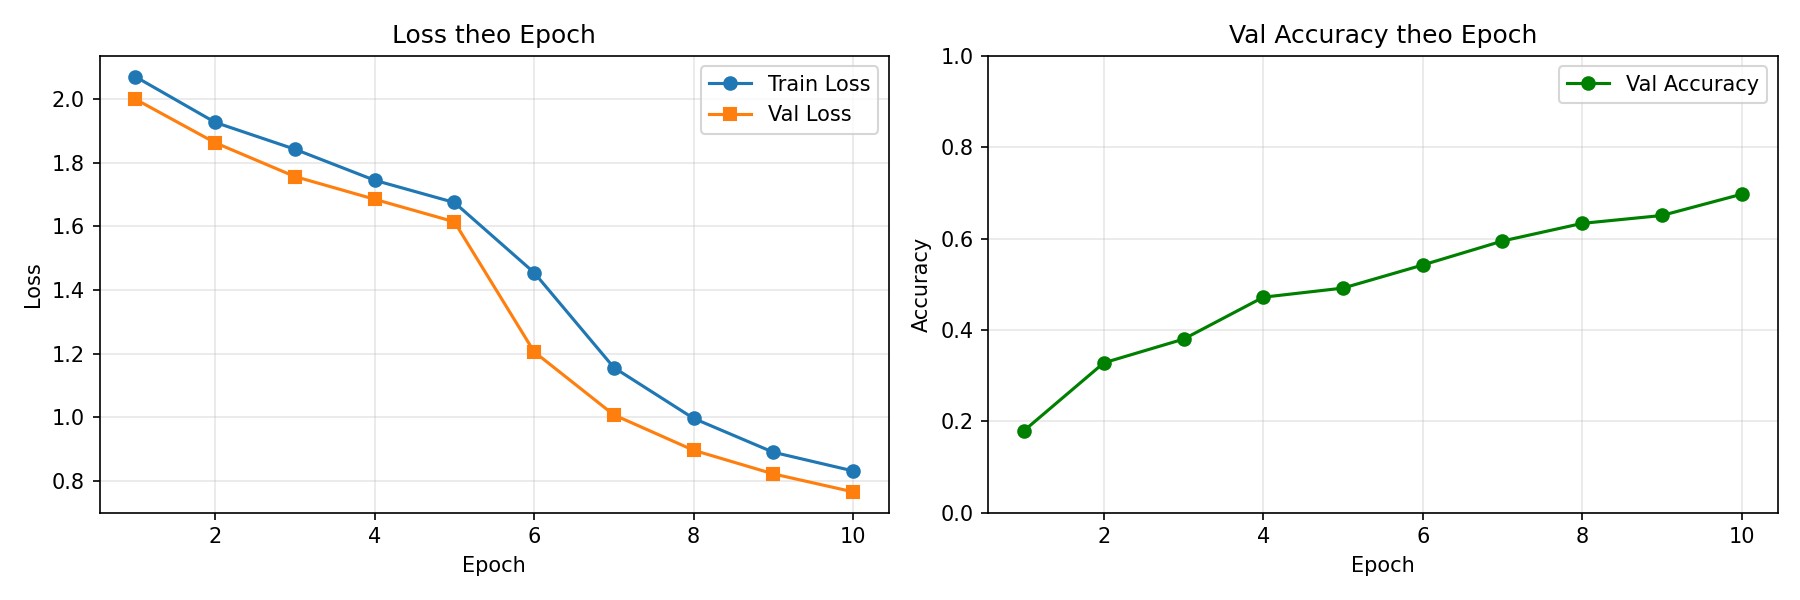

--------------------------------------------------------------------------------


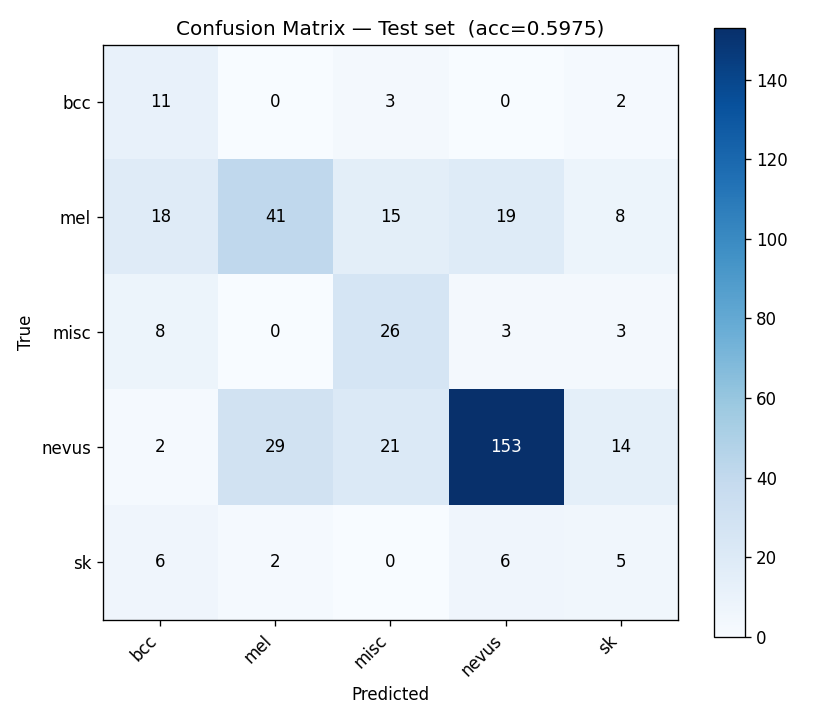

--------------------------------------------------------------------------------


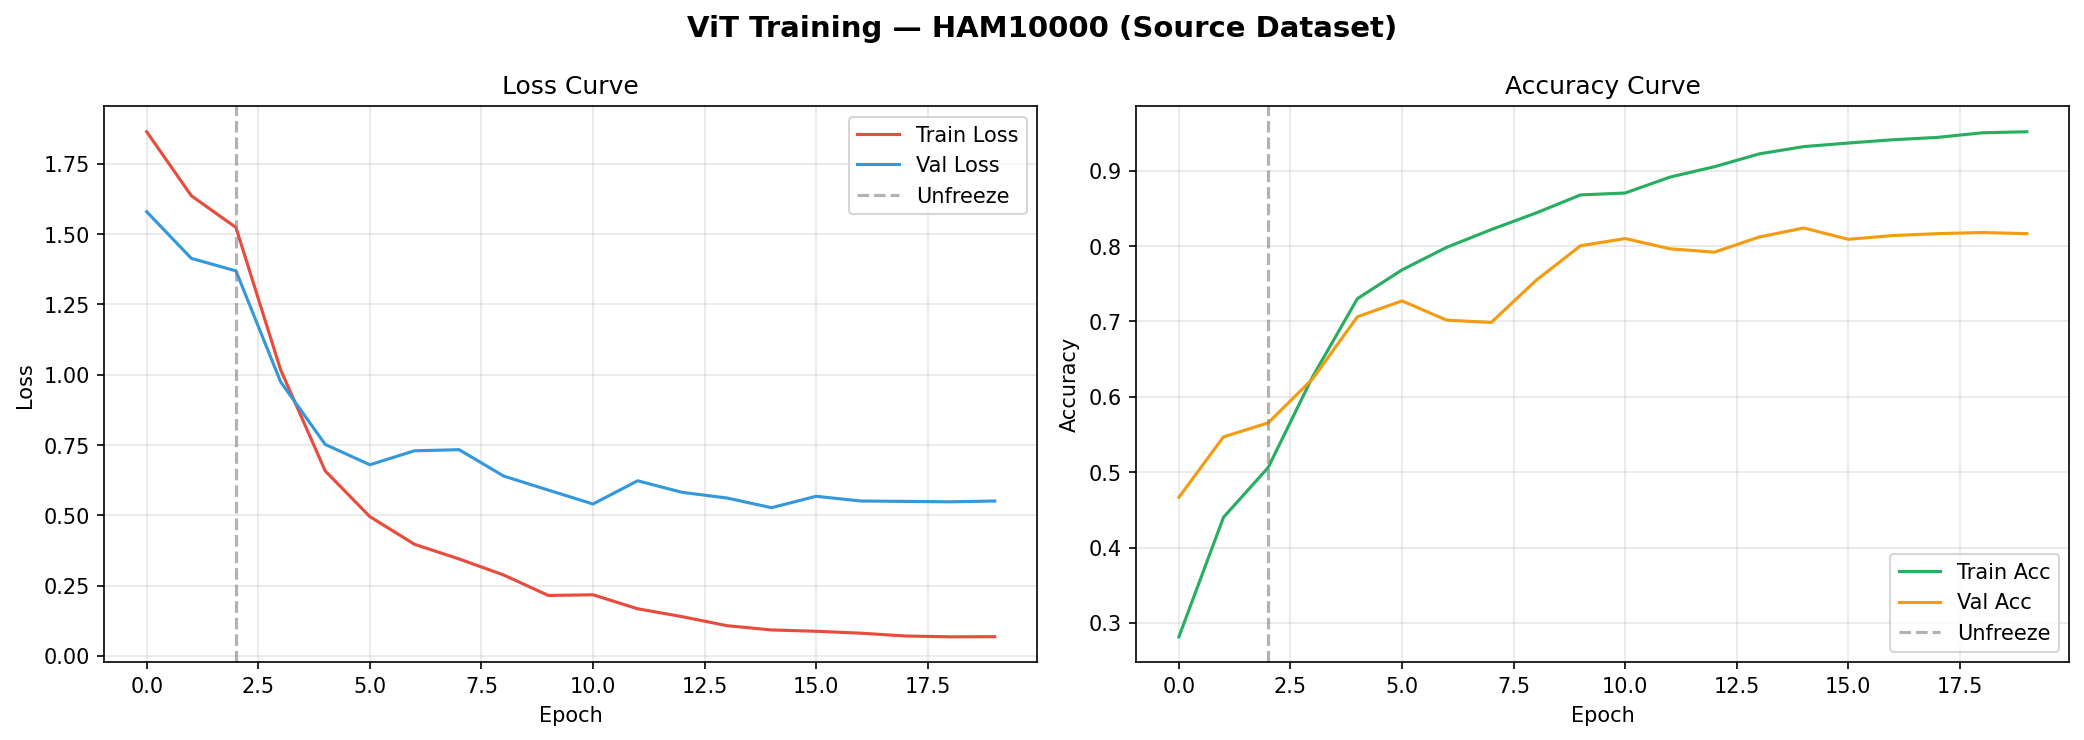

--------------------------------------------------------------------------------


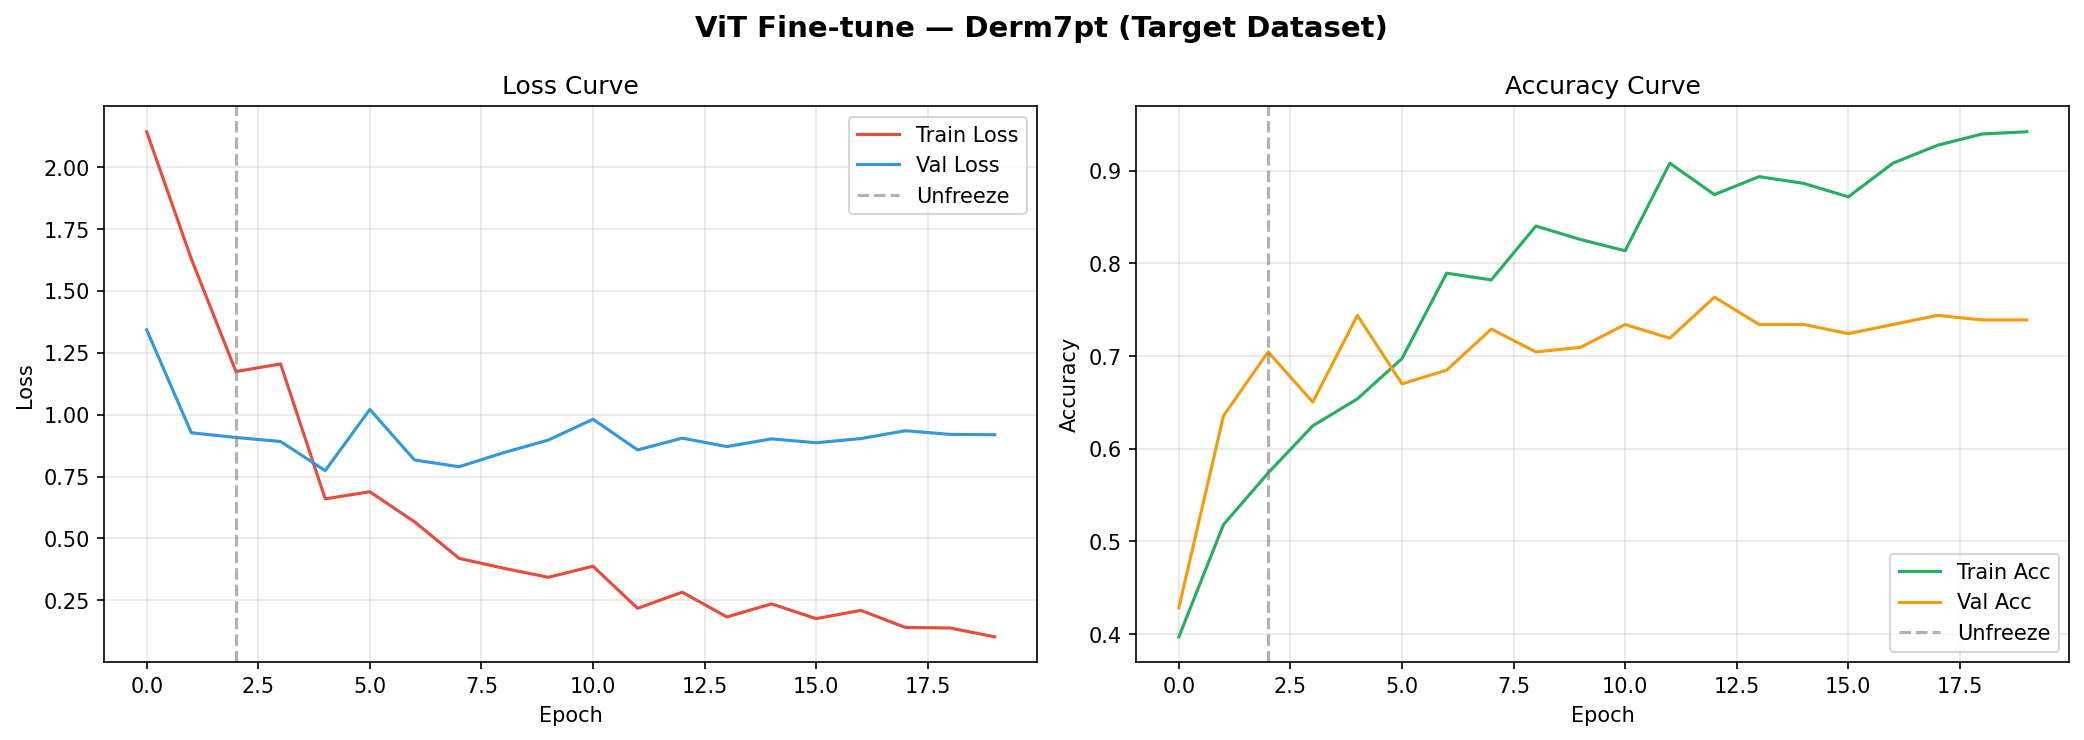

--------------------------------------------------------------------------------


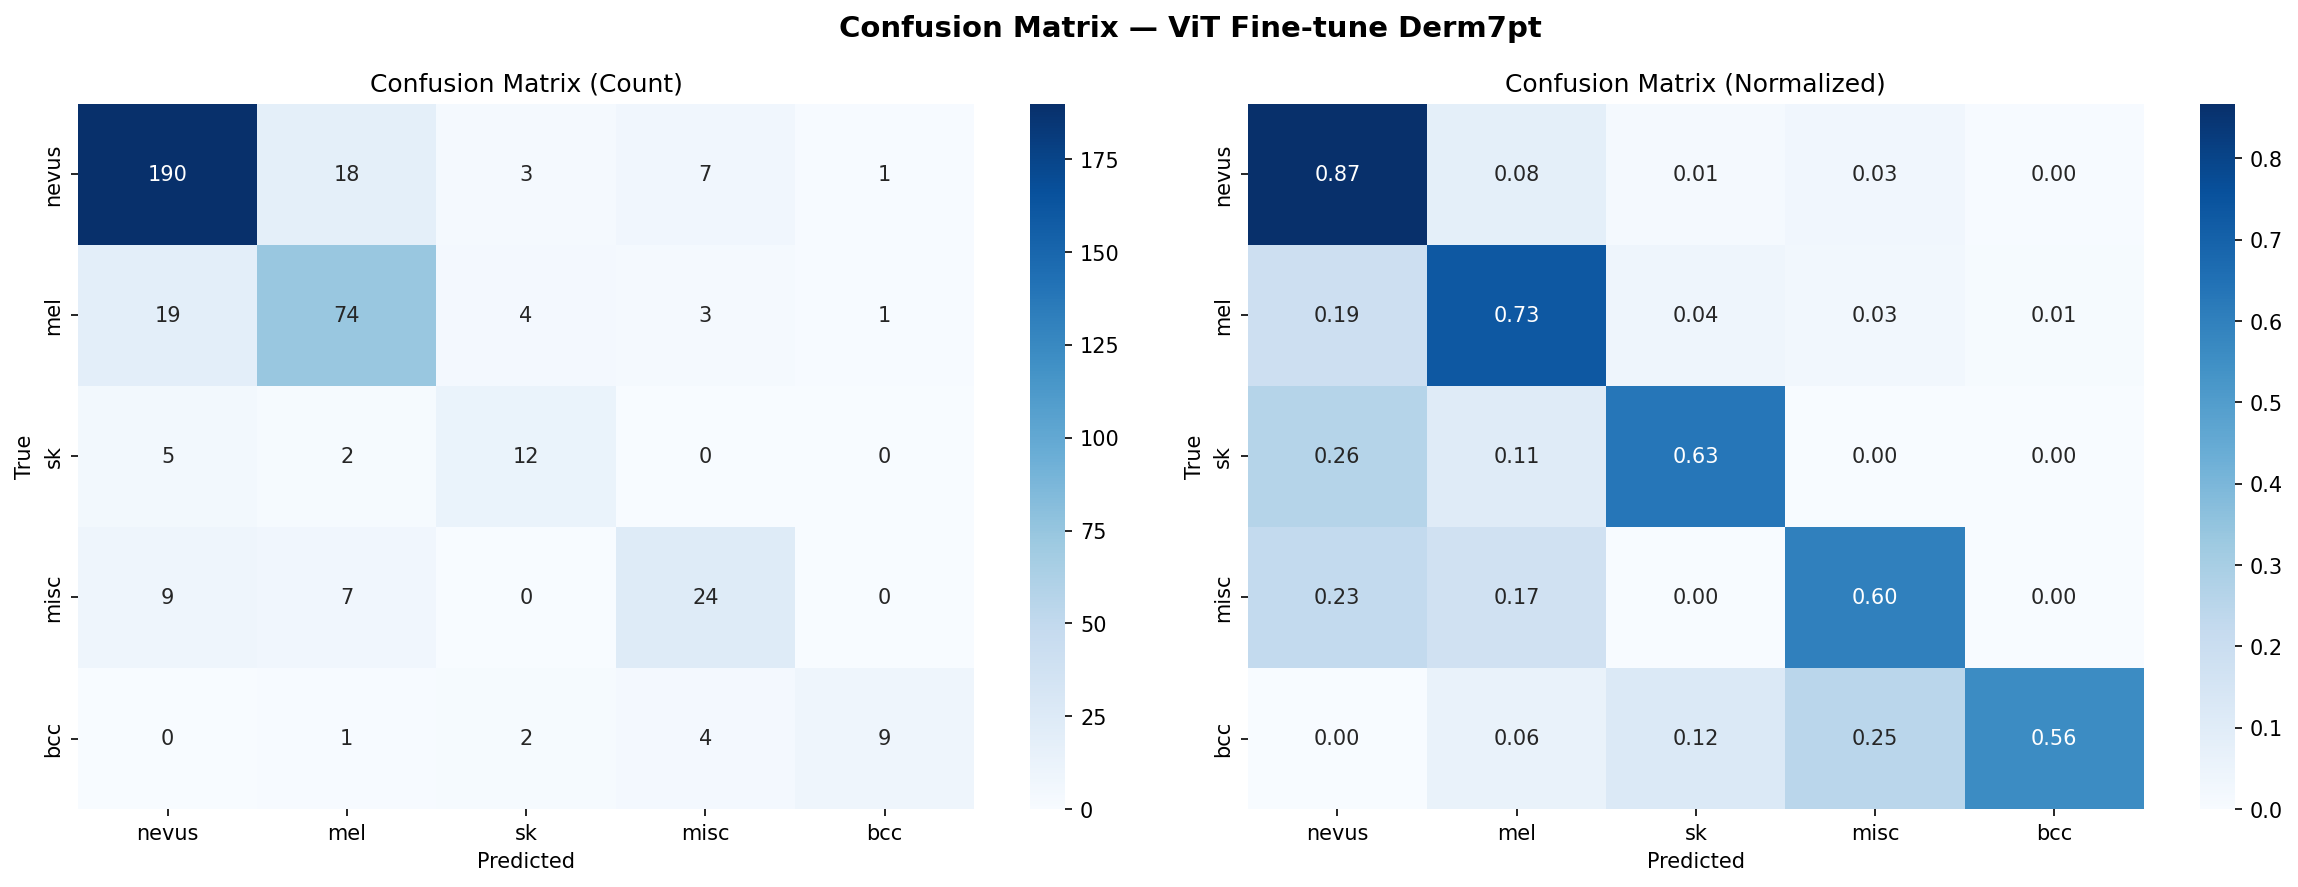

--------------------------------------------------------------------------------


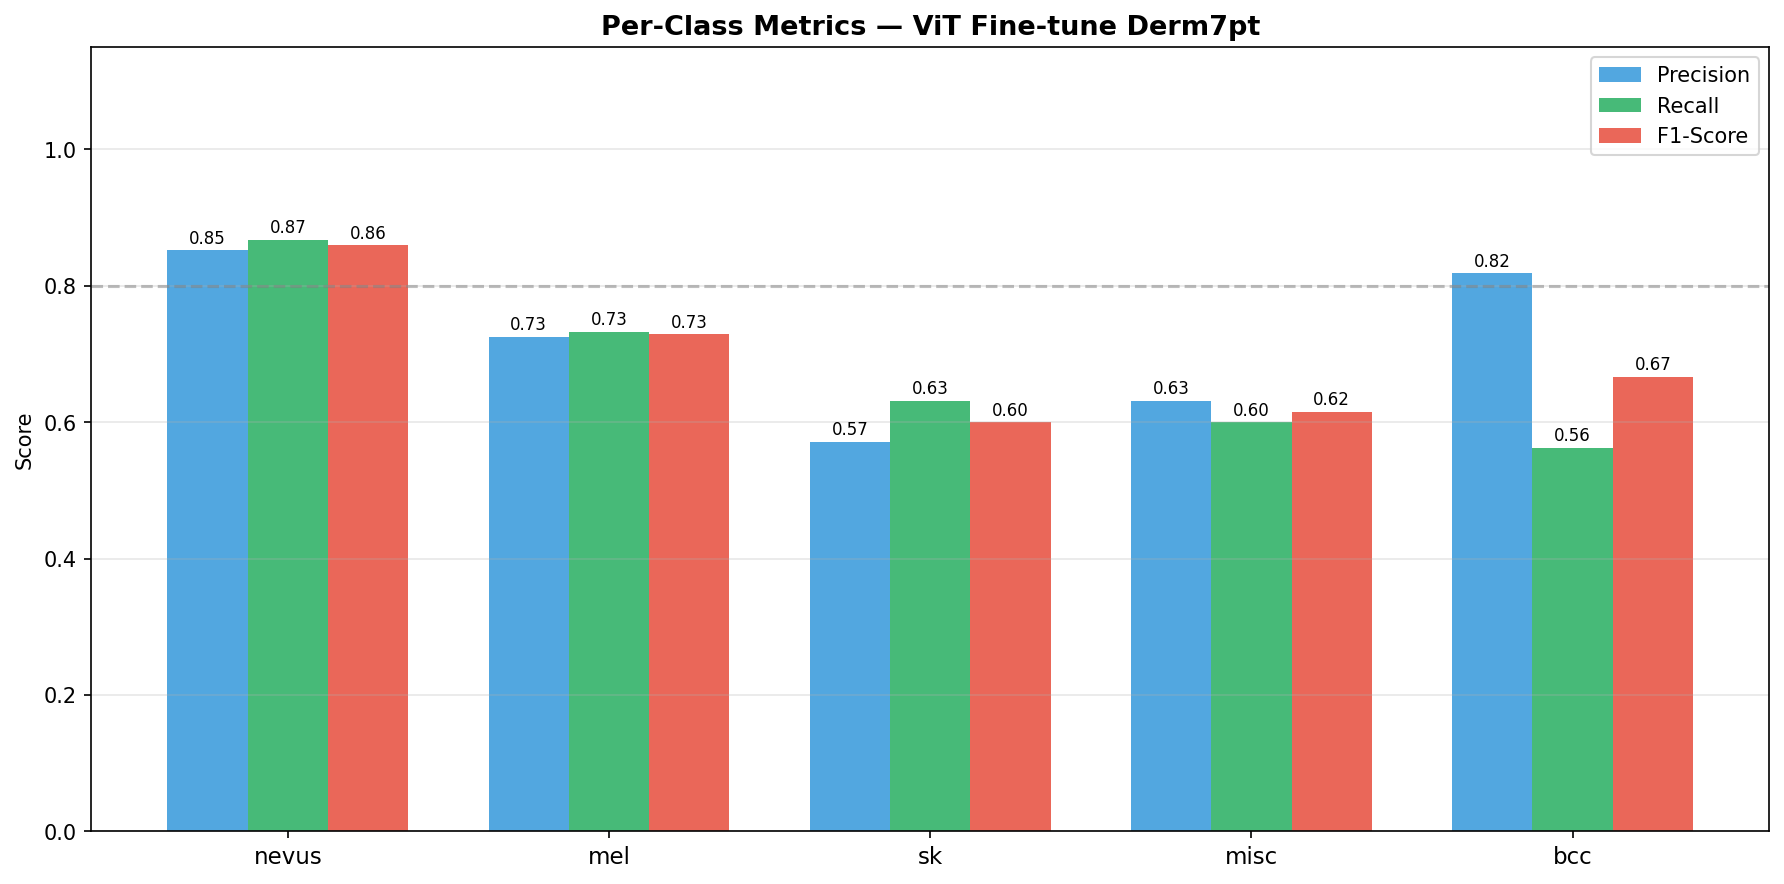

--------------------------------------------------------------------------------


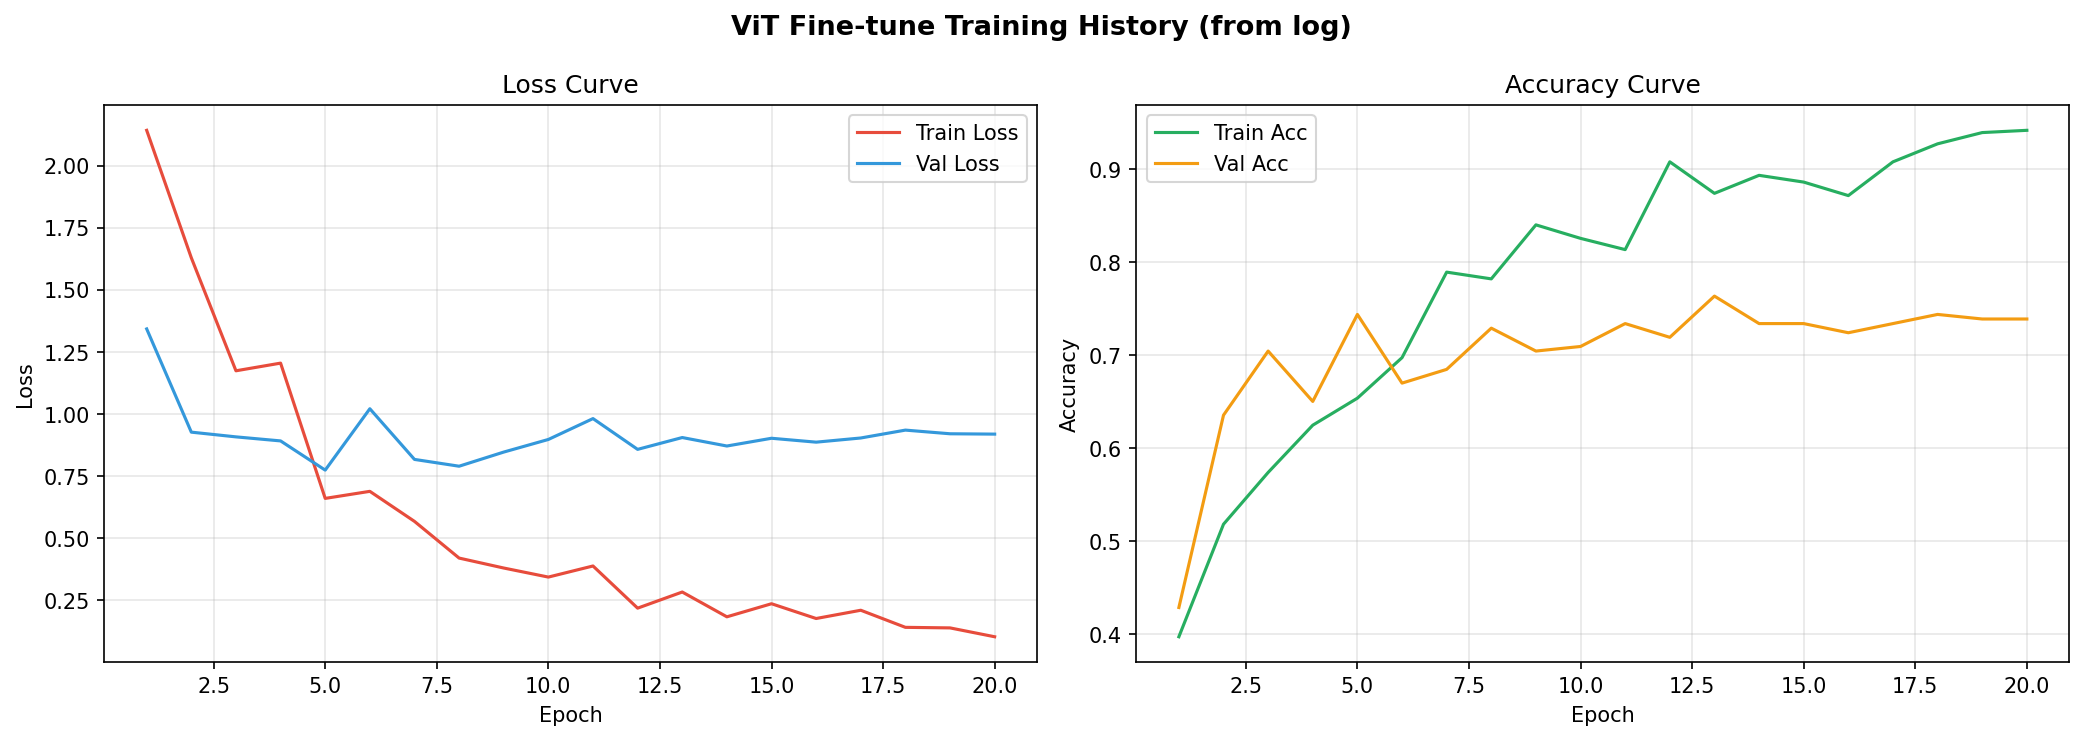

--------------------------------------------------------------------------------


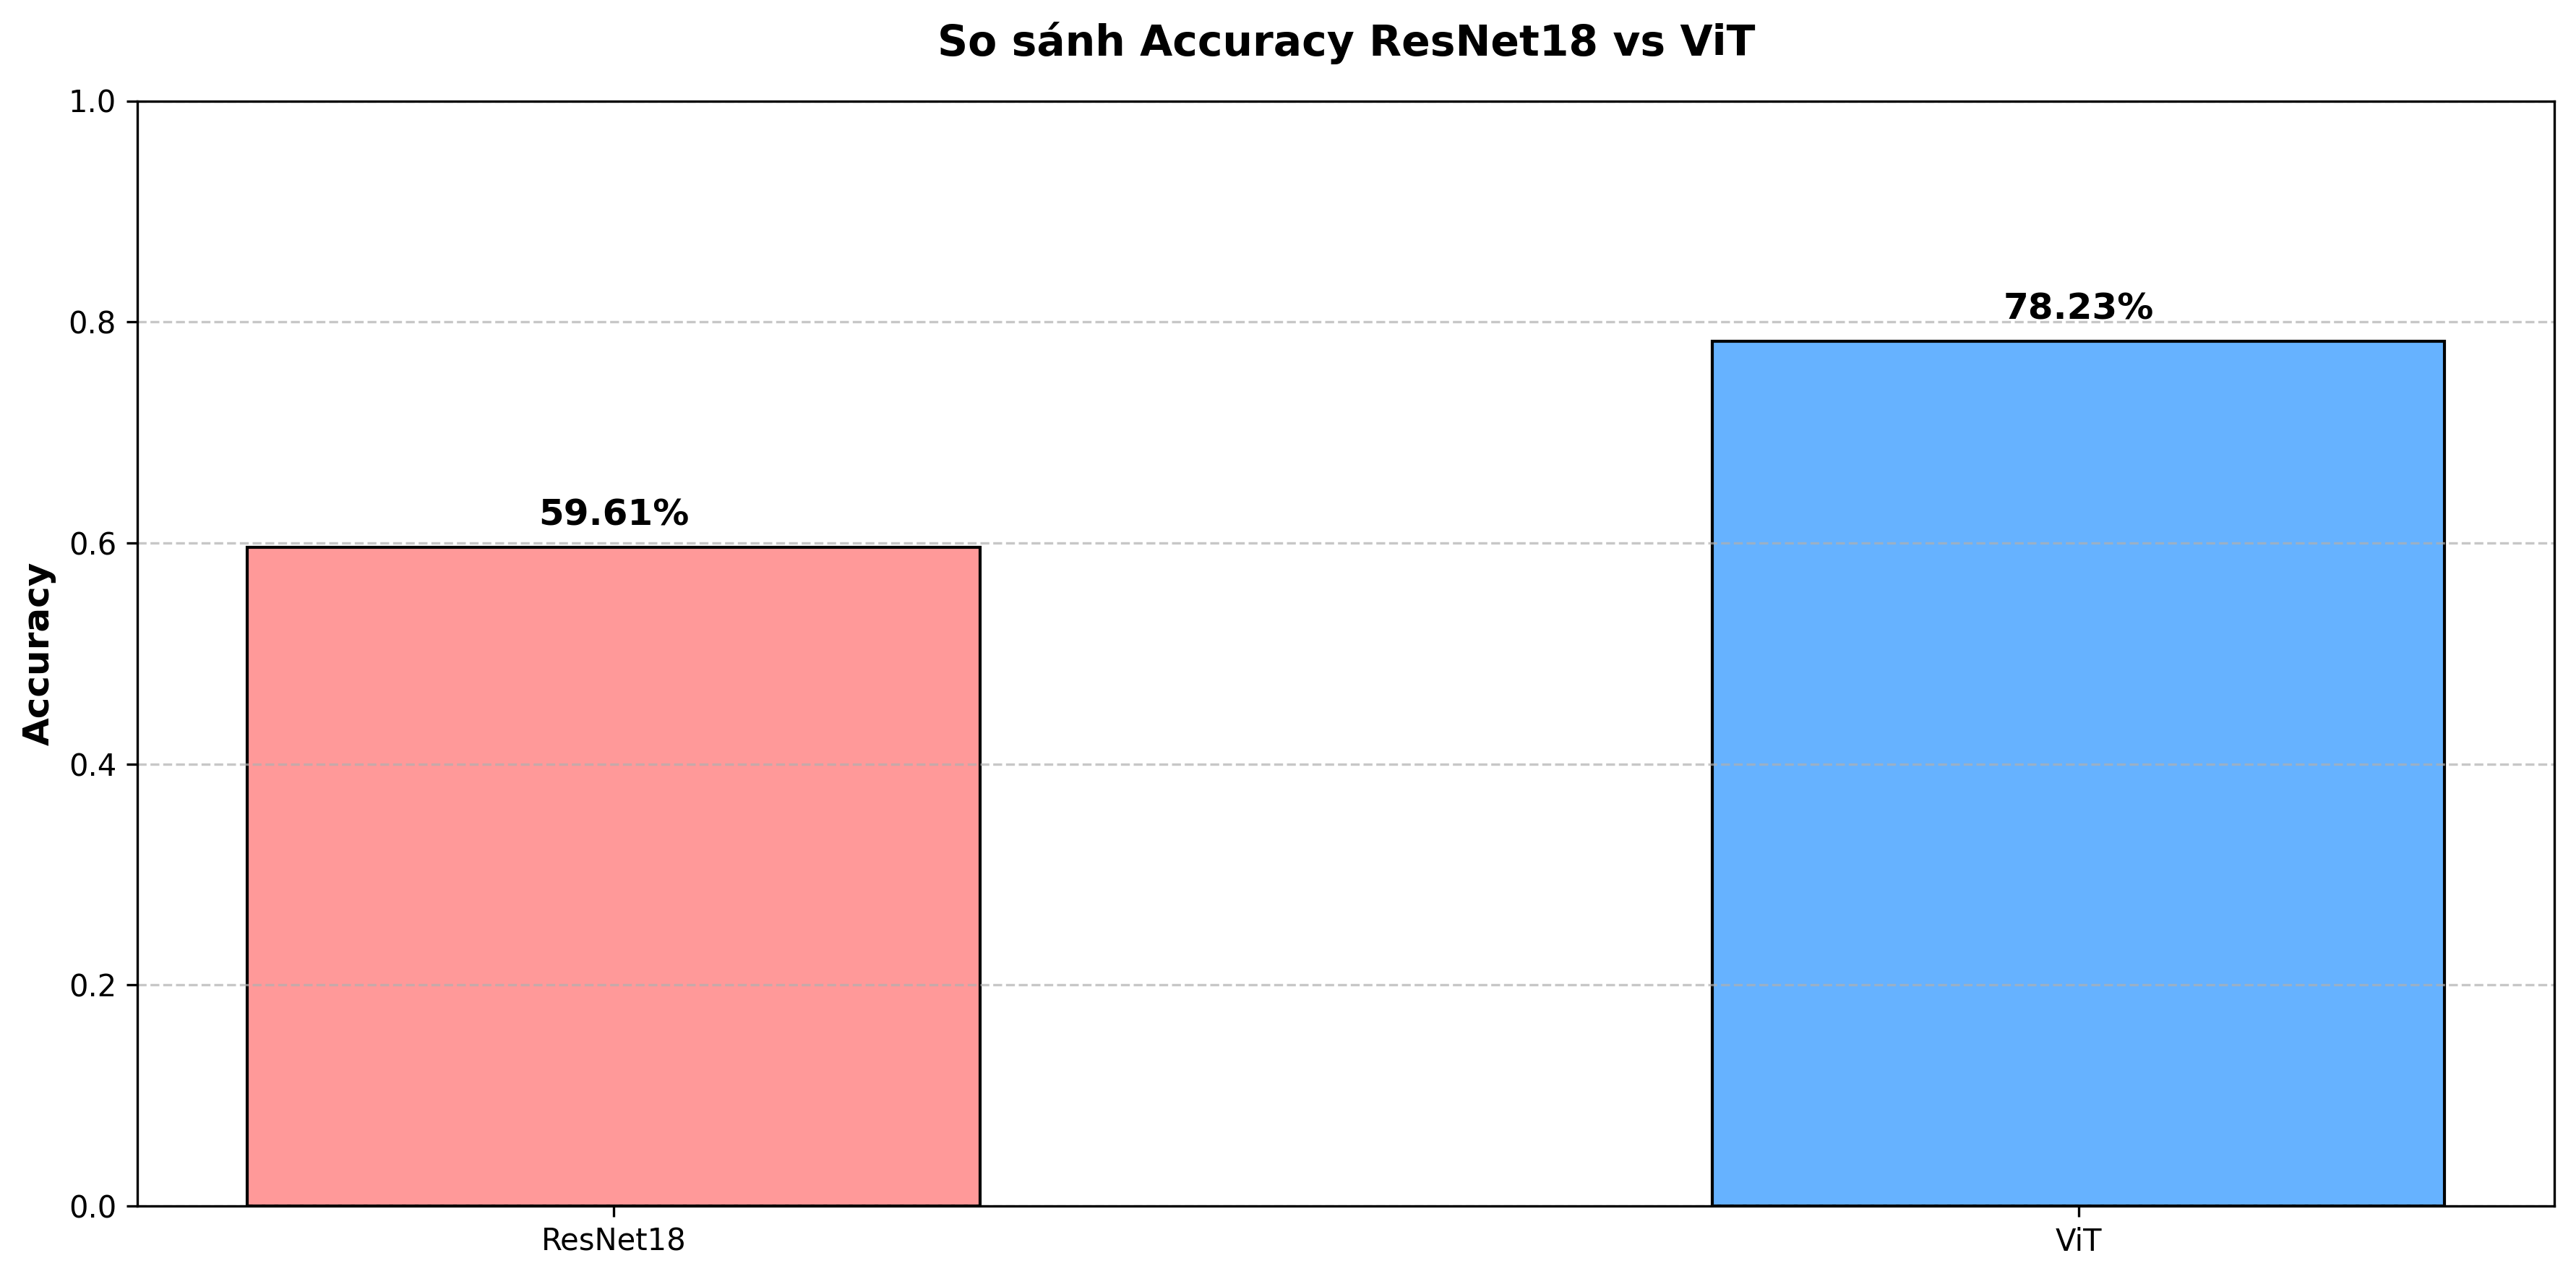

--------------------------------------------------------------------------------


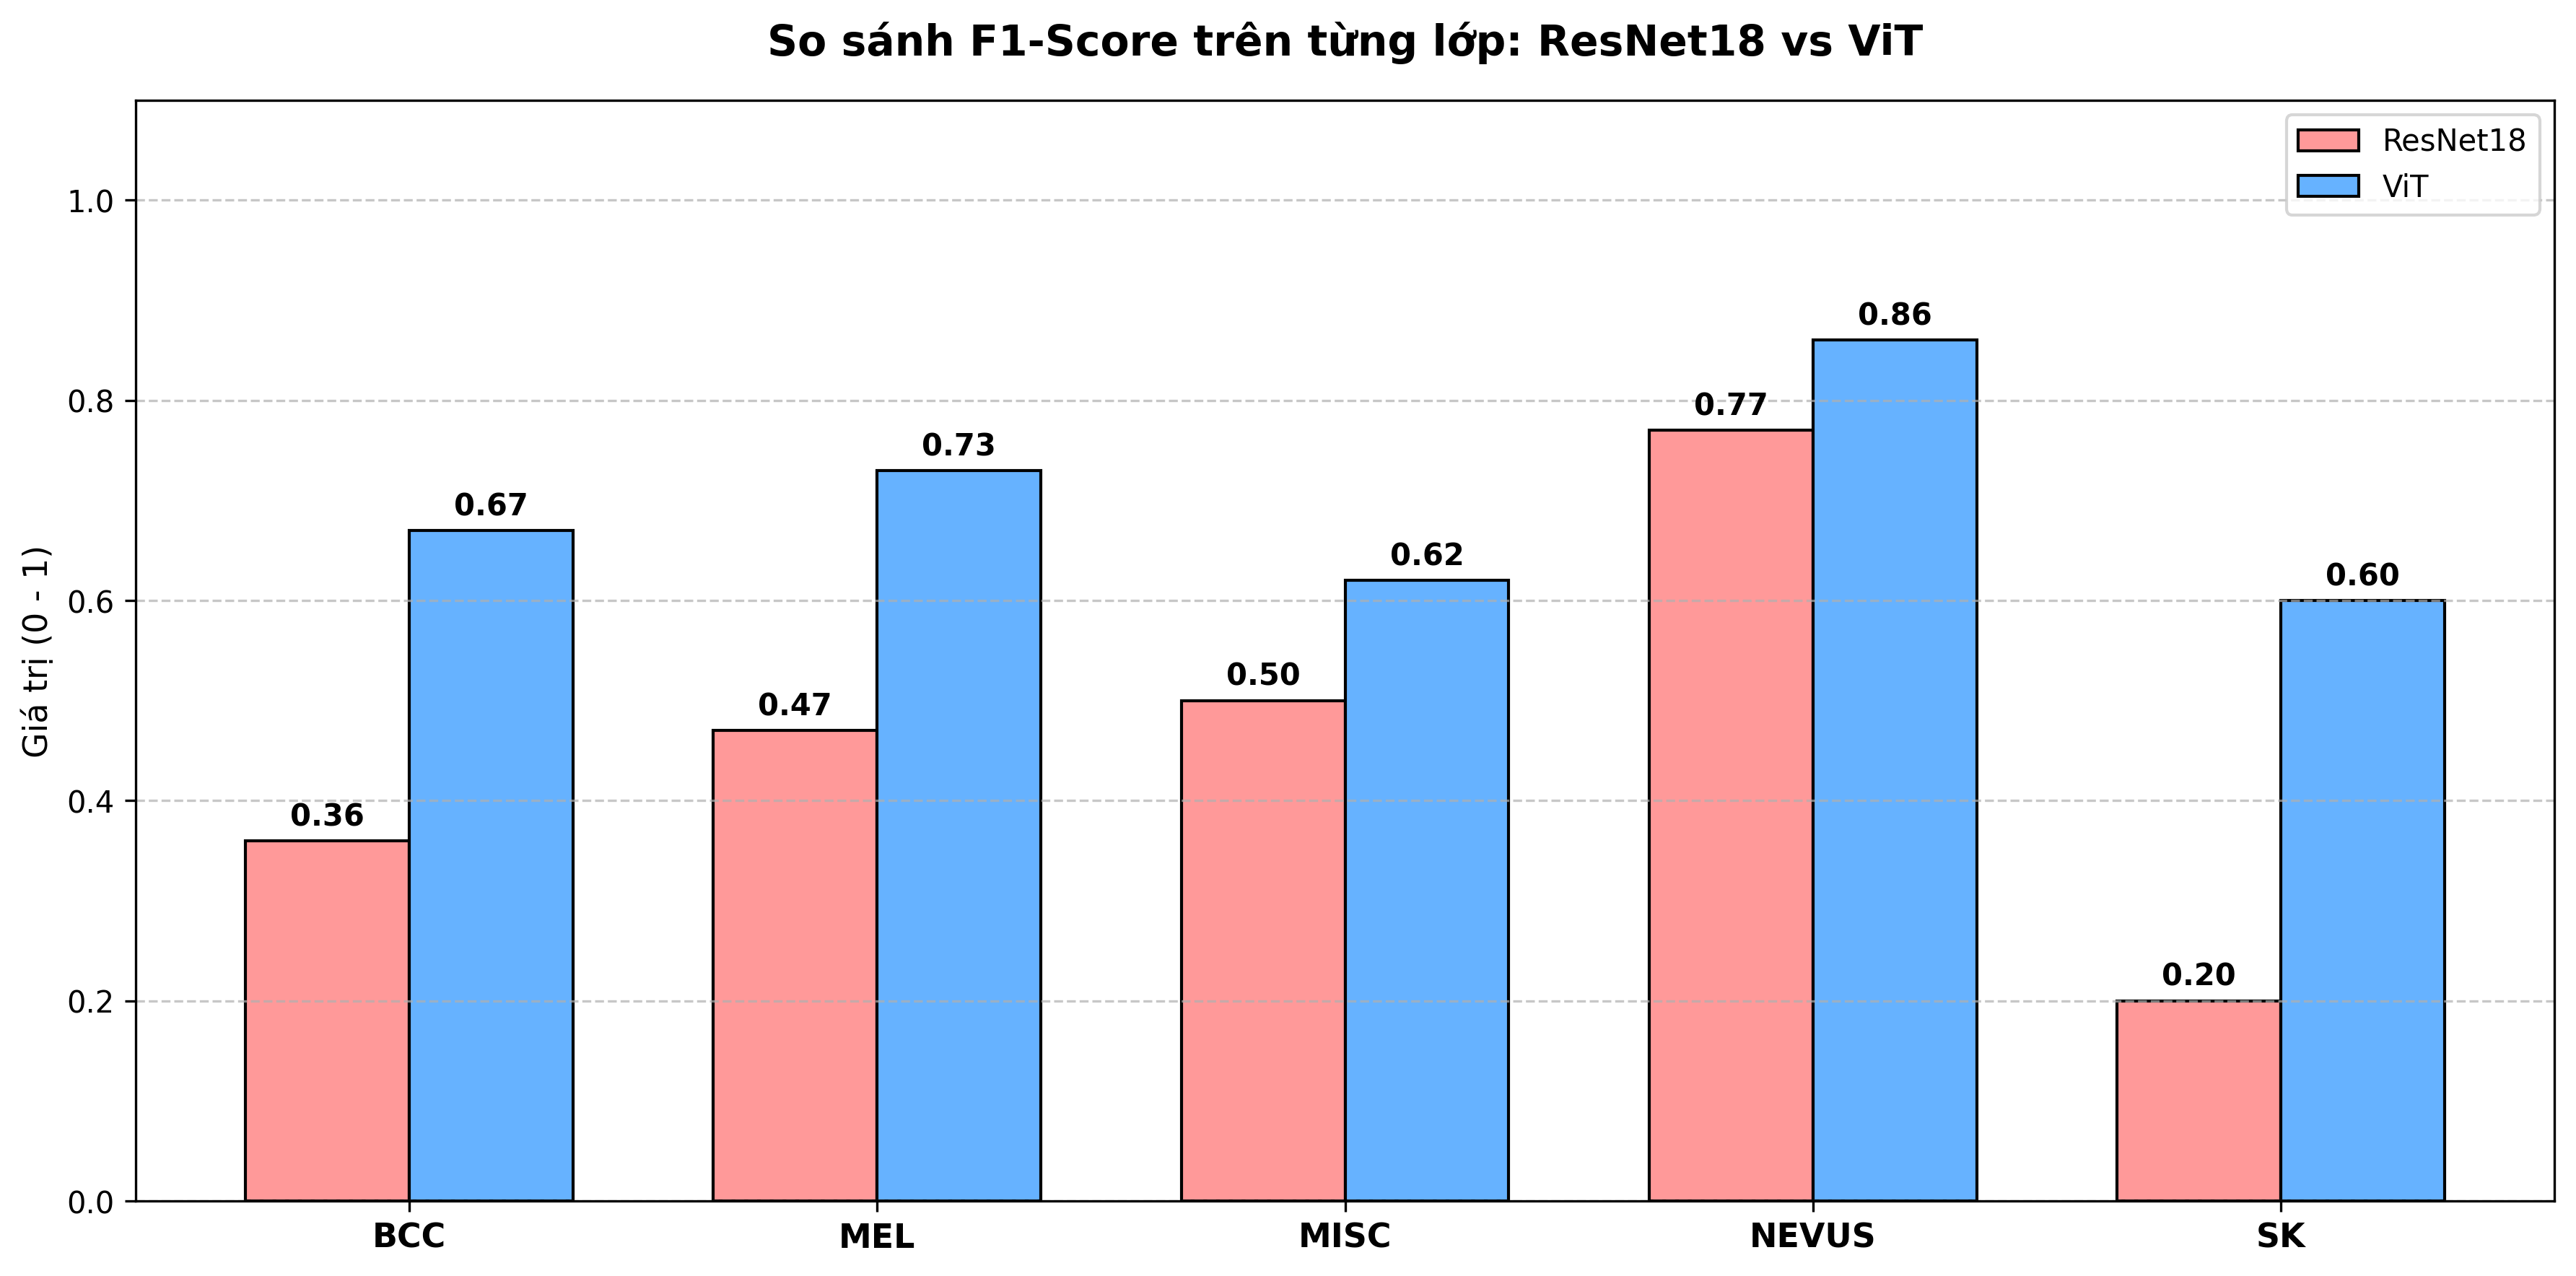

--------------------------------------------------------------------------------


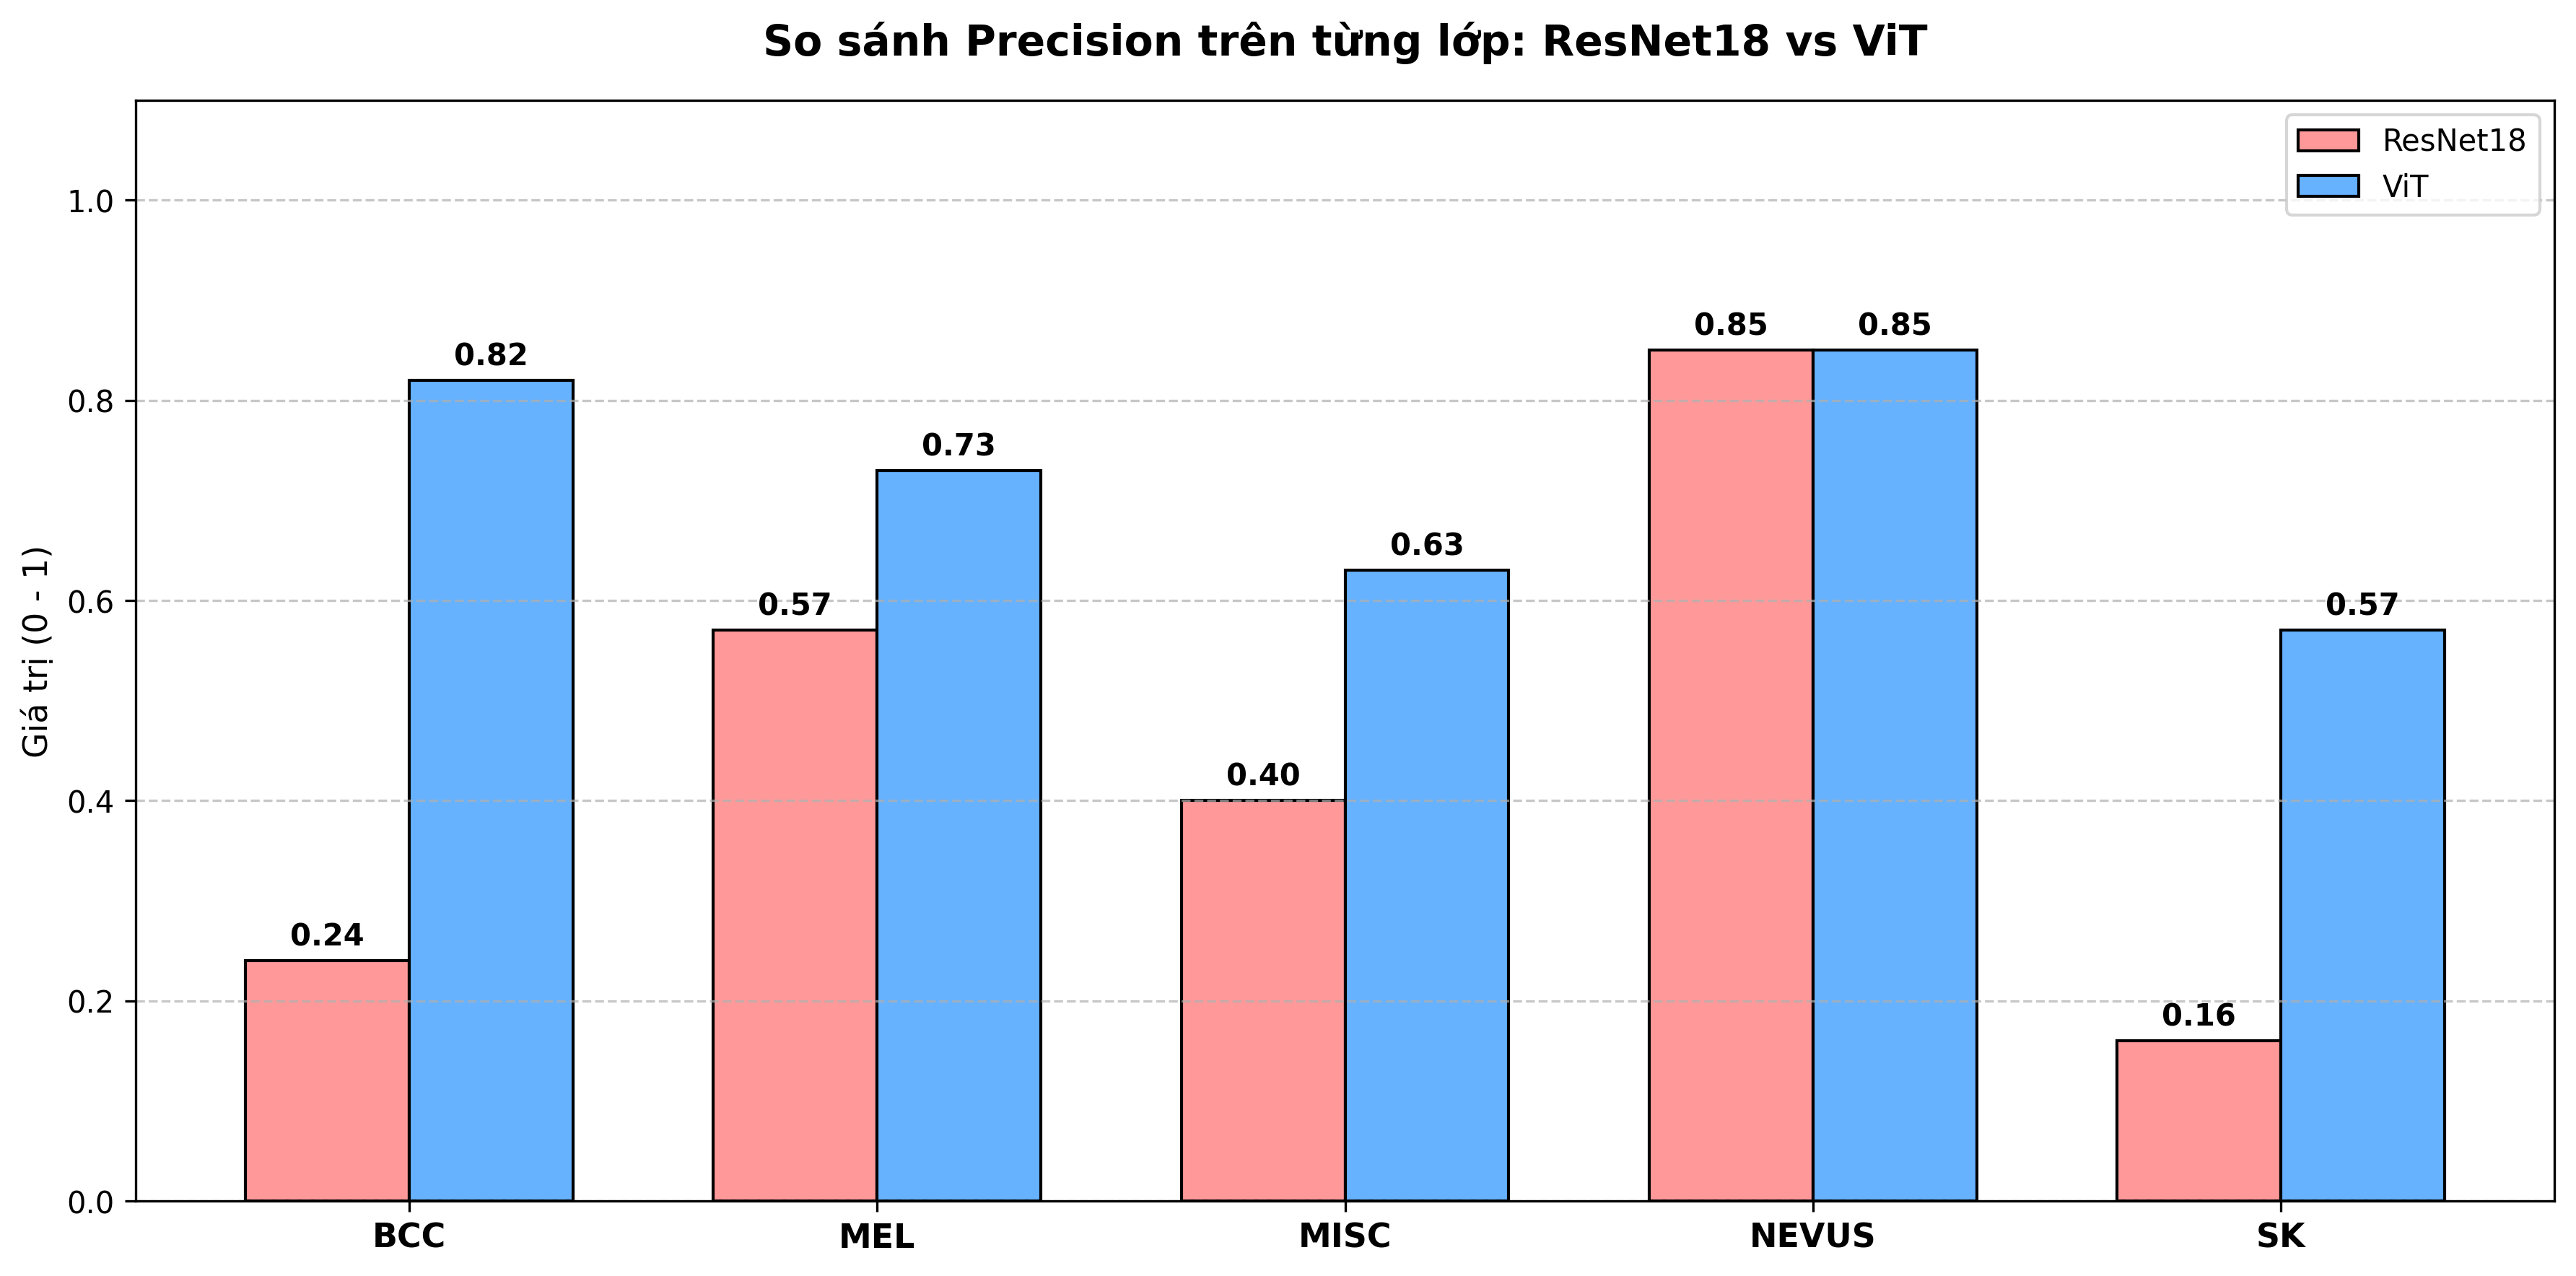

--------------------------------------------------------------------------------


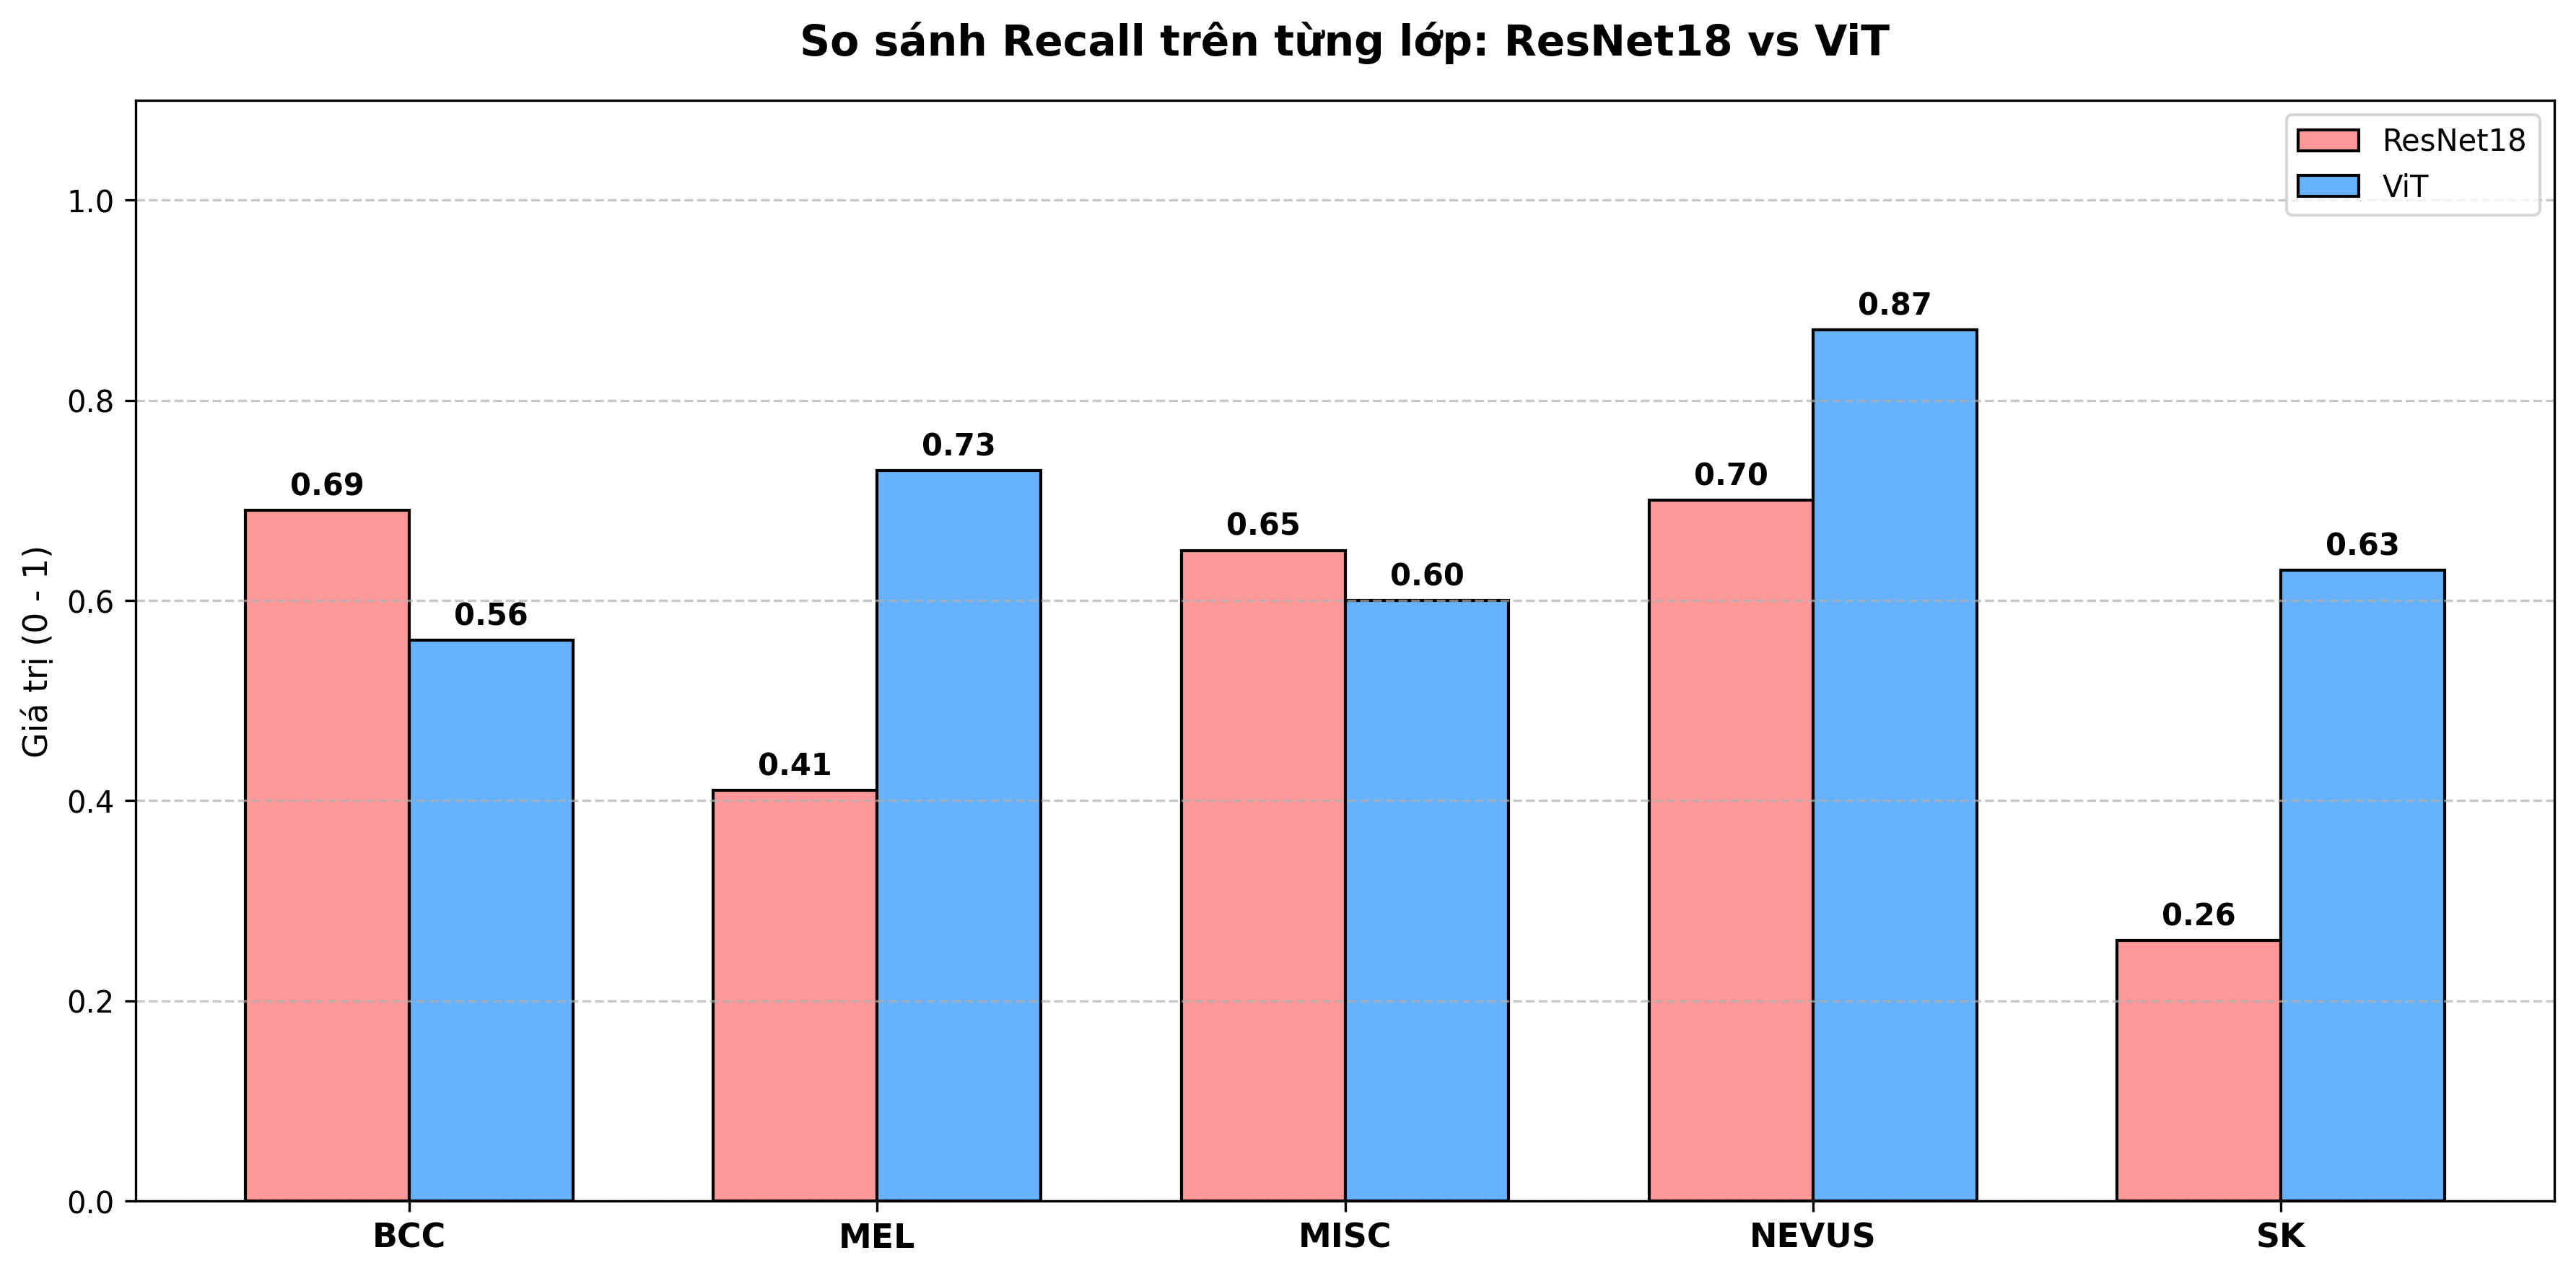

--------------------------------------------------------------------------------


In [32]:
def display_visualizations_custom_order(base_path=".."):
    print("PHẦN 3: VISUALIZATIONS")
    print("="*80)
    
    results_dir = os.path.join(base_path, "results")
    
    if not os.path.exists(results_dir):
        print(f"Không tìm thấy thư mục {results_dir}.")
        return

    all_images = []
    for root, dirs, files in os.walk(results_dir):
        for file in files:
            if file.endswith(('.png', '.jpg', '.jpeg')):
                all_images.append(os.path.join(root, file))
    
    if not all_images:
        print("Không tìm thấy file ảnh (.png/.jpg) nào.")
        return

    bar_charts = []       
    resnet_charts = []   
    vit_charts = []      
    compare_charts = []  
    other_charts = []    

    for img in all_images:
        img_lower = img.lower()
        
        if "fig" in img_lower or "dist" in img_lower:
            bar_charts.append(img)
        elif "comparison" in img_lower or "compare" in img_lower:
            compare_charts.append(img)
        elif "resnet" in img_lower:
            resnet_charts.append(img)
        elif "vit" in img_lower:
            vit_charts.append(img)
        else:
            other_charts.append(img)

    bar_charts.sort()
    compare_charts.sort()
    
    resnet_charts.sort(key=lambda x: (
        0 if 'curve' in x.lower() else (1 if 'confusion' in x.lower() else 2), x
    ))
    
    vit_charts.sort(key=lambda x: (
        0 if 'curve' in x.lower() else (1 if 'matrix' in x.lower() else 2), x
    ))

    ordered_groups = [
        ("1. EDA", bar_charts),
        ("2. KẾT QUẢ MÔ HÌNH RESNET18", resnet_charts),
        ("3. KẾT QUẢ MÔ HÌNH ViT", vit_charts),
        ("4. SO SÁNH HIỆU NĂNG", compare_charts)
    ]
    
    if other_charts:
         ordered_groups.append(("5. CÁC BIỂU ĐỒ KHÁC", other_charts))

    for title, group in ordered_groups:
        if group:
            display(HTML(f"<h2 style='color: #2E86C1; margin-top: 30px; border-bottom: 2px solid #2E86C1; padding-bottom: 5px;'>{title}</h2>"))
            for img_path in group:
                rel_path = os.path.relpath(img_path, results_dir)
                display(HTML(f"<h4> Tệp: <code>{rel_path}</code></h4>"))
                display(Image(filename=img_path))
                print("-" * 80)

display_visualizations_custom_order()